# Healthcare Claim Anomaly Detection — Isolation Forest + SHAP

**Cameroon openIMIS · 14.24M claim headers · scikit-learn**

Companion to `Healthcare_Claim_Autoencoder_Fraud_Detection_FIXED.ipynb`. Sections §1–§6 are
**byte-identical** to that notebook: the same parsers, the same audit gates, the same temporal
split, the same encoders fitted on the same training window. That is deliberate — it is the
only way the two models can be compared honestly. Any difference in the results comes from
the model, not from the pipeline.

---

## Why Isolation Forest for this dataset

| | Autoencoder | Isolation Forest |
|---|---|---|
| Scales to 14.24M rows | yes, on GPU | yes, on CPU — trains on subsamples, scores in O(n) |
| Needs feature scaling | **yes**, and is sensitive to it | no — splits are scale-invariant |
| Handles mixed types | awkwardly (MSE over one-hot blocks is wrong) | natively |
| Hyperparameters | latent size, depth, noise, LR, epochs | `max_samples`, `n_estimators` |
| Per-claim explanation | approximate (SHAP) or exact-but-limited (error decomposition) | **exact Shapley values via TreeSHAP, in milliseconds** |
| Training time on 10M rows | ~1–3 hours on an RTX 2060 | **minutes on CPU** |

The explanation column is the decisive one for a government audit system. TreeSHAP computes
*exact* Shapley values in polynomial time, so every alert can carry a defensible reason
attached at scoring time. For the autoencoder, SHAP is an approximation whose output depends
on the background sample you happen to choose.

Han et al. (*ADBench*, NeurIPS 2022) benchmarked 30 detectors across 57 tabular datasets and
found that simple methods — Isolation Forest, ECOD — match or beat deep autoencoders in the
majority of cases. On 13–40 tabular features, expect this notebook to be **competitive with
or better than** the autoencoder at a small fraction of the cost. If it is, that is the
result, and it should be reported rather than buried.

---

## What is carried over from the review

All twenty-odd defects fixed in the autoencoder rebuild apply here too, because the data
pipeline is shared:

* **D1** — `CareType` / `VisitType` / `HFLevel` are strings, not numbers; one-hot encoded
* **D2** — money parsed with unicode separators, never `fillna(0)`
* **D3** — post-adjudication features (`Approved`, approval ratio) excluded by default
* **D4** — Precision@K divides by the **test** base rate, not the population rate
* **D9** — in-flight claims (status 2/4/8) excluded from the "normal" class
* **D10** — every encoder fitted on the training window only
* **D13/D16** — no destructive clipping; missingness carried as indicators
* **D14** — temporal split
* **D15** — PCA, ECOD-style and single-feature baselines
* **D20** — all metrics and curves from the same full-test array
* **D21** — rejection codes enumerated from the data, not hard-coded

## Isolation Forest specifics addressed here

* **§8** — does training on accepted claims only beat training on everything? (tested, not assumed)
* **§9** — `max_samples` swept properly. The original IF paper recommends **256**, and larger
  values usually make things *worse* through swamping. This is the most commonly mis-set
  parameter in the method.
* **§10** — an ablation that matters only for Isolation Forest: because split points are drawn
  **uniformly at random** between a feature's min and max, a monotone transform like `log1p`
  *does* change the result, unlike in a supervised tree where splits are chosen by criterion.
  On heavy-tailed money this can matter a lot.
* **§18** — TreeSHAP: global leakage screen, per-claim waterfall, and auditor-facing plain
  language.

## §0 — Configuration

In [1]:
import os, gc, json, warnings, datetime as _dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

CONFIG = {
    # ---- paths -------------------------------------------------------------
    "DATA_DIR":  r"../data" if os.path.exists(r"../data/TblClaim.csv") else (r"data" if os.path.exists(r"data/TblClaim.csv") else r"h:\SSD_Backup\Cameroon 2nd Report Codes\data"),
    "MODEL_DIR": r"../model_iforest" if os.path.exists(r"../data") else (r"model_iforest" if os.path.exists(r"model_iforest") else r"h:\SSD_Backup\Cameroon 2nd Report Codes\model_iforest"),

    # ---- D9: which claim statuses count as adjudicated ----------------------
    # 1=REJECTED, 2=ENTERED, 4=CHECKED, 8=PROCESSED, 16=VALUATED, 32=PAYMENT
    "ACCEPTED_STATUSES": (16, 32),
    "REJECTED_STATUSES": (1,),

    # ---- D3: post-adjudication features -------------------------------------
    "USE_POST_ADJUDICATION_FEATURES": False,

    # ---- D2/D22: parsing ---------------------------------------------------
    "MONEY_HAS_DECIMALS": False,
    "MAX_MONEY_UNPARSEABLE_RATE": 0.01,
    "MAX_DATE_NAT_RATE":          0.05,

    # ---- D14: split --------------------------------------------------------
    "SPLIT_MODE": "temporal",
    "SPLIT_DATE_COL": "DateClaimed",
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC":   0.15,

    # ---- Isolation Forest --------------------------------------------------
    # max_samples=256 is the original paper's recommendation. Larger values
    # usually HURT: with more points per tree the anomalies stop being isolated
    # early ("swamping"). Swept properly in §9 rather than guessed.
    "IF_N_ESTIMATORS":    200,
    "IF_MAX_SAMPLES":     256,
    "IF_MAX_FEATURES":    1.0,
    "IF_SWEEP_MAX_SAMPLES":  (64, 128, 256, 512, 1024, 4096),
    "IF_SWEEP_N_ESTIMATORS": (50, 100, 200, 400),
    "IF_SWEEP_MAX_FEATURES": (0.5, 0.75, 1.0),
    "IF_TRAIN_ON": None,          # None => decided empirically in §8; else "accepted"|"all"
    "FIT_SUBSAMPLE": 2_000_000,   # cap rows passed to .fit(); trees draw max_samples anyway

    # ---- §10 ablation ------------------------------------------------------
    "USE_LOG_TRANSFORM": None,    # None => decided empirically; else True|False

    "N_SEEDS": 5,                 # IF is cheap -- no reason not to run more
    "SEED":    42,

    # ---- D12: threshold ----------------------------------------------------
    "THRESHOLD_MODE":   "capacity",       # "capacity" | "cost" | "fbeta"
    "AUDIT_CAPACITY_PER_DAY": 500,
    "F_BETA":           0.5,
    "COST_FN":          15000.0,
    "COST_FP":          2000.0,

    # ---- audit gates -------------------------------------------------------
    "LEAKAGE_CORR_LIMIT": 0.90,
    "MIN_FACILITY_CLAIMS": 100,

    # ---- SHAP --------------------------------------------------------------
    "SHAP_SAMPLE": 5000,          # flagged claims to explain (TreeSHAP is fast, but plots aren't)

    # ---- runtime -----------------------------------------------------------
    "SAMPLE_FRAC": 1.0,
    "CHUNK_SIZE":  2_000_000,
    "EXPECTED_CLAIM_ROWS": 14_242_741,
    "N_JOBS": -1,
}

DATA_DIR  = Path(CONFIG["DATA_DIR"])
MODEL_DIR = Path(CONFIG["MODEL_DIR"]); MODEL_DIR.mkdir(parents=True, exist_ok=True)
CLAIM_FILE    = DATA_DIR / "TblClaim.csv"
SERVICES_FILE = DATA_DIR / "TblClaimServices.csv"
HF_FILE       = DATA_DIR / "TblHF.csv"

SEED = CONFIG["SEED"]
np.random.seed(SEED)

print(f"pandas {pd.__version__} | numpy {np.__version__}")
import sklearn; print(f"scikit-learn {sklearn.__version__}")
print(f"\nPost-adjudication features: "
      f"{'ENABLED (post-payment model)' if CONFIG['USE_POST_ADJUDICATION_FEATURES'] else 'DISABLED (leakage-free)'}")
print(f"Split mode                : {CONFIG['SPLIT_MODE']}")
print("\nNo GPU required. Isolation Forest trains on CPU in minutes.")

pandas 3.0.5 | numpy 2.5.1
scikit-learn 1.9.0

Post-adjudication features: DISABLED (leakage-free)
Split mode                : temporal

No GPU required. Isolation Forest trains on CPU in minutes.


In [2]:
# ---------------------------------------------------------------------------
# Helper functions: parsing, transforms and audit assertions.
# Every one of these exists because of a specific silent failure in the
# original pipeline. They are loud on purpose.
# ---------------------------------------------------------------------------

_SPACE_CHARS = r"[\s\u00A0\u202F\u2009\u2007]"

def parse_money(s: pd.Series, has_decimals: bool = None) -> pd.Series:
    """D2. Parse a currency column that may be stored as text with unicode
    thousands separators (e.g. '5 020', '1 500', '12\u00a0000').

    The original pipeline used pd.to_numeric(..., errors='coerce').fillna(0.0),
    which turns every value >= 1000 into 0.0 without raising. Returns NaN for
    genuinely unparseable values -- never 0.0, because 0 is a meaningful amount.
    """
    if has_decimals is None:
        has_decimals = CONFIG["MONEY_HAS_DECIMALS"]
    if pd.api.types.is_numeric_dtype(s):
        return s.astype("float64")

    t = s.astype("string").str.strip()
    t = t.str.replace(_SPACE_CHARS, "", regex=True)      # unicode spaces
    t = t.str.replace(r"[^\d\.,\-]", "", regex=True)     # currency symbols, letters

    if has_decimals:
        # Rightmost separator followed by 1-2 digits is the decimal mark.
        t = t.str.replace(r"[\.,](?=\d{3}(?:\D|$))", "", regex=True)
        t = t.str.replace(",", ".", regex=False)
    else:
        t = t.str.replace(r"[\.,]", "", regex=True)      # XAF has no minor unit

    t = t.replace({"": pd.NA, "-": pd.NA})
    return pd.to_numeric(t, errors="coerce").astype("float64")


DATE_FORMATS = [
    "%d %b, %Y, %H:%M", "%d %b, %Y, %H:%M:%S", "%d %b, %Y",
    "%Y-%m-%d %H:%M:%S.%f", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d",
    "%d/%m/%Y %H:%M", "%d/%m/%Y", "%m/%d/%Y",
]

def parse_dates(s: pd.Series, formats=DATE_FORMATS) -> pd.Series:
    """D22. Explicit format cascade instead of per-element inference.

    pd.to_datetime without format= silently returns NaT for the minority format
    when a column mixes two ('2 Apr, 2025' and '9 Apr, 2025, 20:40'), and those
    NaTs then cascaded into LOS=1.0 / delay=0.0 via the original fillna calls.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    t = s.astype("string").str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    todo = out.isna() & t.notna()
    for fmt in formats:
        if not todo.any():
            break
        parsed = pd.to_datetime(t[todo], format=fmt, errors="coerce")
        out.loc[todo] = parsed
        todo = out.isna() & t.notna()
    if todo.any():                                   # last-resort inference
        try:
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce",
                                           format="mixed", dayfirst=True)
        except (TypeError, ValueError):
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", dayfirst=True)
    return out


def signed_log1p(x):
    """D13/D17. Compress heavy tails while preserving sign.

    The original clip(0, ...) destroyed exactly the signals the features were
    engineered to detect: negative length-of-stay (1,420 invalid date intervals
    per the DQ report), backdated submissions, and Approved > Claimed.
    """
    x = np.asarray(x, dtype="float64")
    return np.sign(x) * np.log1p(np.abs(x))


def assert_rows(df, expected, label):
    """D23. Merges against SCD Type 2 tables can silently fan out rows."""
    if expected is not None and len(df) != expected:
        raise AssertionError(
            f"[{label}] row count changed: {len(df):,} != {expected:,}. "
            "A merge key is probably non-unique (TblHF is SCD Type 2)."
        )
    print(f"  [ok] {label}: {len(df):,} rows")


def report_series(name, s, n=8):
    nn = s.notna().mean()
    print(f"  {name:<28} dtype={str(s.dtype):<16} non-null={nn:6.2%}  "
          f"sample={list(s.dropna().unique()[:n])}")

print("Helpers loaded: parse_money, parse_dates, signed_log1p, assert_rows, report_series")

Helpers loaded: parse_money, parse_dates, signed_log1p, assert_rows, report_series


## §1 — Pre-flight data integrity gate (D1, D2, D22)

**Read this output before running anything else.**

The two most damaging defects in the original pipeline were invisible: three feature columns
were constant zero and the financial columns were mass-zeroed, and neither raised an error.
This cell samples the raw CSVs, prints the real dtypes and values, and **raises** if money or
dates fail to parse above the configured tolerance.

In [4]:
PREFLIGHT_N = 200_000

print("=" * 78)
print("PRE-FLIGHT DATA INTEGRITY CHECK")
print("=" * 78)

_pf_cols = ["ClaimStatus", "Claimed", "Approved", "CareType", "VisitType",
            "DateFrom", "DateTo", "DateClaimed", "Hfid", "Icdid", "RejectionReason"]
pf = pd.read_csv(CLAIM_FILE, nrows=PREFLIGHT_N, dtype=str, usecols=lambda c: c in _pf_cols)

print(f"\n[1] RAW COLUMN TYPES AND VALUES  (first {PREFLIGHT_N:,} rows of TblClaim.csv)")
for c in _pf_cols:
    if c in pf.columns:
        report_series(c, pf[c])
    else:
        print(f"  {c:<28} *** COLUMN NOT FOUND ***")

# ---- D2: money -------------------------------------------------------------
print("\n[2] MONEY PARSING (D2)")
money_fail = {}
for col in ["Claimed", "Approved"]:
    if col not in pf.columns:
        continue
    raw   = pf[col]
    naive = pd.to_numeric(raw, errors="coerce")          # what the original did
    fixed = parse_money(raw)
    present = raw.notna()
    naive_bad = (present & naive.isna()).sum() / max(present.sum(), 1)
    fixed_bad = (present & fixed.isna()).sum() / max(present.sum(), 1)
    money_fail[col] = fixed_bad
    print(f"  {col}:")
    print(f"    original to_numeric unparseable : {naive_bad:7.2%}   "
          f"(these became 0.0 and were treated as real amounts)")
    print(f"    parse_money unparseable         : {fixed_bad:7.2%}")
    print(f"    mean  original -> fixed         : {naive.fillna(0).mean():12,.1f} -> {fixed.mean():12,.1f}")
    print(f"    max   original -> fixed         : {naive.fillna(0).max():12,.1f} -> {fixed.max():12,.1f}")
    ex = pd.DataFrame({"raw": raw, "naive": naive, "parse_money": fixed})
    ex = ex[ex["naive"].isna() & ex["parse_money"].notna()].head(5)
    if len(ex):
        print("    examples the original silently zeroed:")
        for _, r in ex.iterrows():
            print(f"        {r['raw']!r:>18}  ->  original 0.0   |   fixed {r['parse_money']:,.0f}")

# ---- D1: categoricals ------------------------------------------------------
print("\n[3] CATEGORICAL COLUMNS (D1)")
for col in ["CareType", "VisitType"]:
    if col not in pf.columns:
        continue
    numeric_ok = pd.to_numeric(pf[col], errors="coerce").notna().mean()
    print(f"  {col:<12} numeric-coercible: {numeric_ok:6.2%}  "
          f"levels: {sorted(pf[col].dropna().unique().tolist())[:10]}")
    if numeric_ok < 0.5:
        print(f"       -> the original produced a CONSTANT ZERO column here. "
              f"Now one-hot encoded.")

if HF_FILE.exists():
    hf_pf = pd.read_csv(HF_FILE, dtype=str, usecols=["HfID", "HFLevel"])
    numeric_ok = pd.to_numeric(hf_pf["HFLevel"], errors="coerce").notna().mean()
    print(f"  {'HFLevel':<12} numeric-coercible: {numeric_ok:6.2%}  "
          f"levels: {sorted(hf_pf['HFLevel'].dropna().unique().tolist())[:10]}")
    if numeric_ok < 0.5:
        print(f"       -> the original produced a CONSTANT ZERO column here. "
              f"Now one-hot encoded.")
    dup = hf_pf["HfID"].duplicated().sum()
    print(f"  TblHF HfID duplicates: {dup:,}  "
          f"{'(fan-out risk -- deduplicated in §2)' if dup else '(unique)'}")

# ---- D22: dates ------------------------------------------------------------
print("\n[4] DATE PARSING (D22)")
date_fail = {}
for col in ["DateFrom", "DateTo", "DateClaimed"]:
    if col not in pf.columns:
        continue
    present = pf[col].notna()
    naive = pd.to_datetime(pf[col], errors="coerce")
    fixed = parse_dates(pf[col])
    nb = (present & naive.isna()).sum() / max(present.sum(), 1)
    fb = (present & fixed.isna()).sum() / max(present.sum(), 1)
    date_fail[col] = fb
    print(f"  {col:<14} original NaT: {nb:7.2%}   parse_dates NaT: {fb:7.2%}")

# ---- D9: status distribution ----------------------------------------------
print("\n[5] CLAIM STATUS DISTRIBUTION (D9)")
if "ClaimStatus" in pf.columns:
    vc = pd.to_numeric(pf["ClaimStatus"], errors="coerce").value_counts(dropna=False)
    names = {1: "REJECTED", 2: "ENTERED", 4: "CHECKED", 8: "PROCESSED",
             16: "VALUATED", 32: "PAYMENT"}
    keep = set(CONFIG["ACCEPTED_STATUSES"]) | set(CONFIG["REJECTED_STATUSES"])
    for st, n in vc.items():
        tag = "keep" if st in keep else "DROP (in-flight)"
        print(f"  status {str(st):>5} {names.get(st,'?'):<10} {n:>10,}  {n/len(pf):7.2%}   {tag}")
    kept = vc[[s for s in vc.index if s in keep]].sum()
    print(f"  -> {kept/len(pf):.2%} of claims are fully adjudicated and will be used")

# ---- D21: rejection codes present at header level --------------------------
print("\n[6] REJECTION CODES AT CLAIM-HEADER LEVEL (D21)")
if "RejectionReason" in pf.columns:
    rc = pf["RejectionReason"].fillna("<null>").value_counts().head(15)
    print(f"  observed values: {rc.to_dict()}")
    print("  note: the DQ report's code taxonomy (3,4,5,7,-1,...) is measured on")
    print("        TblClaimServices line items. Codes absent here are reported in §15.")

# ---- GATE ------------------------------------------------------------------
print("\n" + "=" * 78)
problems = []
for c, r in money_fail.items():
    if r > CONFIG["MAX_MONEY_UNPARSEABLE_RATE"]:
        problems.append(f"{c}: {r:.2%} of money values unparseable "
                        f"(limit {CONFIG['MAX_MONEY_UNPARSEABLE_RATE']:.2%})")
for c, r in date_fail.items():
    if r > CONFIG["MAX_DATE_NAT_RATE"]:
        problems.append(f"{c}: {r:.2%} of dates unparseable "
                        f"(limit {CONFIG['MAX_DATE_NAT_RATE']:.2%})")

if problems:
    print("PRE-FLIGHT FAILED")
    for p in problems:
        print("  - " + p)
    raise AssertionError(
        "Fix the parser configuration before continuing. Inspect the raw values "
        "printed above and adjust MONEY_HAS_DECIMALS / DATE_FORMATS in CONFIG. "
        "Do NOT proceed by lowering the tolerance -- the original pipeline's "
        "headline results were produced by exactly this class of silent failure."
    )
print("PRE-FLIGHT PASSED -- safe to continue")
print("=" * 78)

del pf; gc.collect()

PRE-FLIGHT DATA INTEGRITY CHECK

[1] RAW COLUMN TYPES AND VALUES  (first 200,000 rows of TblClaim.csv)
  ClaimStatus                  dtype=str              non-null=100.00%  sample=['16', '4', '1', '8', '2', '32']
  Claimed                      dtype=str              non-null=100.00%  sample=['5 020', '600', '7 000', '5 000', '2 075', '5 905', '2 500', '62 770']
  Approved                     dtype=str              non-null=73.18%  sample=['5 020', '600', '7 000', '5 000', '2 000', '4 000', '2 500', '62 770']
  CareType                     dtype=str              non-null= 0.45%  sample=['OPD', 'IPD']
  VisitType                    dtype=str              non-null=100.00%  sample=['O', 'R', 'E', ' ']
  DateFrom                     dtype=str              non-null=100.00%  sample=['2 Apr, 2025', '8 Apr, 2025', '3 Apr, 2025', '4 Apr, 2025', '9 Apr, 2025', '1 Apr, 2025', '5 Apr, 2025', '6 Apr, 2025']
  DateTo                       dtype=str              non-null=100.00%  sample=['2 Apr, 202

0

## §2 — Ingestion and feature engineering (D2, D9, D13, D16, D22, D23)

Changes from the original:

* money and dates go through the validated parsers, not `to_numeric` / `to_datetime`
* only fully adjudicated claims survive (D9) — in-flight claims have NULL `Approved`,
  which the original imputed to 0 and therefore made indistinguishable from a rejection
* nothing is clipped to zero; sign is preserved and the anomalous conditions get
  explicit binary flags instead of being erased (D13)
* missing values are recorded as `_isna` indicators rather than imputed to 0 (D16)
* row counts are asserted after every merge (D23)

In [5]:
# ---------------------------------------------------------------------------
# 2.1  Service line-item aggregates
# ---------------------------------------------------------------------------
print("Aggregating TblClaimServices.csv ...")
df_services = pd.read_csv(SERVICES_FILE, usecols=["ClaimID", "PriceAsked"],
                          dtype={"PriceAsked": str}, low_memory=False)
df_services["PriceAsked"] = parse_money(df_services["PriceAsked"])   # D2

print(f"  line items                 : {len(df_services):,}")
print(f"  PriceAsked unparseable     : {df_services['PriceAsked'].isna().mean():.3%}")
print(f"  PriceAsked mean / max      : {df_services['PriceAsked'].mean():,.1f} / "
      f"{df_services['PriceAsked'].max():,.1f}")

srv_agg = (df_services.groupby("ClaimID")["PriceAsked"]
           .agg(SVC_Count="count", SVC_TotalAsked="sum",
                SVC_MaxPrice="max", SVC_MeanPrice="mean")
           .reset_index())
assert srv_agg["ClaimID"].is_unique, "srv_agg ClaimID not unique"
print(f"  claims with service lines  : {len(srv_agg):,}")

del df_services; gc.collect()

Aggregating TblClaimServices.csv ...
  line items                 : 15,774,762
  PriceAsked unparseable     : 0.000%
  PriceAsked mean / max      : 225,519.8 / 700,070,007,000.0
  claims with service lines  : 14,547,637


0

In [6]:
# ---------------------------------------------------------------------------
# 2.2  Health facility metadata  (D1: HFLevel stays categorical, D23: uniqueness)
# ---------------------------------------------------------------------------
if HF_FILE.exists():
    df_hf = pd.read_csv(HF_FILE, usecols=["HfID", "HFLevel", "HFCareType", "LegalForm"],
                        dtype=str, low_memory=False)
    df_hf["HfID"] = pd.to_numeric(df_hf["HfID"], errors="coerce")
    before = len(df_hf)
    df_hf = df_hf.dropna(subset=["HfID"]).drop_duplicates(subset=["HfID"], keep="last")
    df_hf["HfID"] = df_hf["HfID"].astype("int64")
    print(f"TblHF: {before:,} rows -> {len(df_hf):,} unique facilities "
          f"({before - len(df_hf):,} SCD Type 2 duplicates collapsed)")
    assert df_hf["HfID"].is_unique, "HfID still not unique -- merge would fan out"
    for c in ["HFLevel", "HFCareType", "LegalForm"]:
        df_hf[c] = df_hf[c].fillna("UNKNOWN").astype(str).str.strip().str.upper()
        print(f"  {c:<12} levels: {sorted(df_hf[c].unique().tolist())[:12]}")
else:
    df_hf = None
    print("TblHF.csv not found -- facility attributes will be UNKNOWN")

TblHF: 2,512 rows -> 2,512 unique facilities (0 SCD Type 2 duplicates collapsed)
  HFLevel      levels: ['C', 'D', 'H']
  HFCareType   levels: ['B', 'I', 'O']
  LegalForm    levels: ['C', 'D', 'G', 'P']


In [7]:
# ---------------------------------------------------------------------------
# 2.3  Claim headers, chunked
# ---------------------------------------------------------------------------
USECOLS = ["ClaimID", "ClaimStatus", "RejectionReason", "Claimed", "Approved",
           "DateFrom", "DateTo", "DateClaimed", "Hfid", "Icdid",
           "CareType", "VisitType"]

ACCEPTED = set(CONFIG["ACCEPTED_STATUSES"])
REJECTED = set(CONFIG["REJECTED_STATUSES"])
KEEP_STATUS = ACCEPTED | REJECTED

chunks, n_raw, n_dropped_status = [], 0, 0
rng_sample = np.random.default_rng(SEED)

print("Ingesting TblClaim.csv ...")
for i, ch in enumerate(pd.read_csv(CLAIM_FILE, usecols=USECOLS, dtype=str,
                                   chunksize=CONFIG["CHUNK_SIZE"], low_memory=False)):
    n_raw += len(ch)
    if CONFIG["SAMPLE_FRAC"] < 1.0:
        ch = ch.loc[rng_sample.random(len(ch)) < CONFIG["SAMPLE_FRAC"]].copy()

    ch["ClaimID"]     = pd.to_numeric(ch["ClaimID"], errors="coerce")
    ch["ClaimStatus"] = pd.to_numeric(ch["ClaimStatus"], errors="coerce")

    # ---- D9: keep only fully adjudicated claims ---------------------------
    before = len(ch)
    ch = ch[ch["ClaimStatus"].isin(KEEP_STATUS)].copy()
    n_dropped_status += before - len(ch)
    if ch.empty:
        continue

    ch["y"] = ch["ClaimStatus"].isin(REJECTED).astype("int8")
    ch["RejectionCode"] = (ch["RejectionReason"].fillna("0").astype(str)
                             .str.strip().str.replace(r"\.0$", "", regex=True))

    # ---- facility attributes (D1, D23) ------------------------------------
    ch["Hfid"]  = pd.to_numeric(ch["Hfid"],  errors="coerce").fillna(-1).astype("int64")
    ch["Icdid"] = pd.to_numeric(ch["Icdid"], errors="coerce").fillna(-1).astype("int64")
    if df_hf is not None:
        n_before = len(ch)
        ch = ch.merge(df_hf, left_on="Hfid", right_on="HfID", how="left")
        assert len(ch) == n_before, "TblHF merge fanned out rows"
        for c in ["HFLevel", "HFCareType", "LegalForm"]:
            ch[c] = ch[c].fillna("UNKNOWN")
    else:
        for c in ["HFLevel", "HFCareType", "LegalForm"]:
            ch[c] = "UNKNOWN"

    # ---- service aggregates (D16: absence is a signal, not a 1) -----------
    n_before = len(ch)
    ch = ch.merge(srv_agg, on="ClaimID", how="left")
    assert len(ch) == n_before, "srv_agg merge fanned out rows"
    ch["FLAG_no_service_lines"] = ch["SVC_Count"].isna().astype("int8")

    # ---- money (D2) -------------------------------------------------------
    claimed  = parse_money(ch["Claimed"])
    approved = parse_money(ch["Approved"])
    ch["NUM_Claimed"] = claimed
    ch["ISNA_Claimed"] = claimed.isna().astype("int8")
    ch["FLAG_neg_claimed"] = (claimed < 0).fillna(False).astype("int8")

    # ---- dates (D22) ------------------------------------------------------
    d_from    = parse_dates(ch["DateFrom"])
    d_to      = parse_dates(ch["DateTo"])
    d_claimed = parse_dates(ch["DateClaimed"])
    ch["DateClaimed_parsed"] = d_claimed

    los   = (d_to - d_from).dt.days
    delay = (d_claimed - d_to).dt.days
    ch["NUM_LengthOfStay"]   = los                     # D13: sign preserved
    ch["NUM_SubmissionDelay"] = delay                  # D13: sign preserved
    ch["ISNA_LengthOfStay"]   = los.isna().astype("int8")
    ch["ISNA_SubmissionDelay"] = delay.isna().astype("int8")
    ch["FLAG_negative_los"]  = (los < 0).fillna(False).astype("int8")
    ch["FLAG_backdated"]     = (delay < 0).fillna(False).astype("int8")
    ch["FLAG_los_over_year"] = (los > 365).fillna(False).astype("int8")

    # ---- derived (relative features beat absolute ones) -------------------
    ch["NUM_ServiceCount"]     = ch["SVC_Count"]
    ch["NUM_ServiceTotalAsked"] = ch["SVC_TotalAsked"]
    ch["NUM_ServiceMaxPrice"]  = ch["SVC_MaxPrice"]
    ch["NUM_ClaimServiceGap"]  = claimed - ch["SVC_TotalAsked"]
    ch["NUM_CostPerDay"]       = claimed / los.abs().clip(lower=1)
    ch["NUM_CostPerService"]   = claimed / ch["SVC_Count"].clip(lower=1)

    # ---- D3: post-adjudication outcomes, only if explicitly enabled -------
    if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
        ch["NUM_Approved"]        = approved
        ch["NUM_ClaimedMinusApproved"] = claimed - approved     # sign preserved
        ch["NUM_ApprovalRatio"]   = np.where(claimed.notna() & (claimed != 0),
                                             approved / claimed, np.nan)
        ch["FLAG_approved_over_claimed"] = (approved > claimed).fillna(False).astype("int8")

    keep = (["ClaimID", "y", "RejectionCode", "Hfid", "Icdid", "DateClaimed_parsed",
             "CareType", "VisitType", "HFLevel", "HFCareType", "LegalForm"]
            + [c for c in ch.columns if c.startswith(("NUM_", "FLAG_", "ISNA_"))])
    chunks.append(ch[keep].copy())
    print(f"  chunk {i+1}: kept {len(ch):,}")
    del ch; gc.collect()

df = pd.concat(chunks, ignore_index=True)
del chunks, srv_agg; gc.collect()

if CONFIG["SAMPLE_FRAC"] >= 1.0 and CONFIG["EXPECTED_CLAIM_ROWS"]:
    assert n_raw == CONFIG["EXPECTED_CLAIM_ROWS"], \
        f"read {n_raw:,} rows, expected {CONFIG['EXPECTED_CLAIM_ROWS']:,}"

print(f"\nRaw claim headers read       : {n_raw:,}")
print(f"Dropped as in-flight (D9)    : {n_dropped_status:,}")
print(f"Adjudicated claims retained  : {len(df):,}")
print(f"Rejection rate (population)  : {df['y'].mean():.4%}")
print(f"Date range                   : {df['DateClaimed_parsed'].min()} .. "
      f"{df['DateClaimed_parsed'].max()}")

Ingesting TblClaim.csv ...
  chunk 1: kept 415,083
  chunk 2: kept 356,849
  chunk 3: kept 430,288
  chunk 4: kept 345,238
  chunk 5: kept 438,072
  chunk 6: kept 378,463
  chunk 7: kept 351,733
  chunk 8: kept 69,698

Raw claim headers read       : 14,242,741
Dropped as in-flight (D9)    : 11,457,317
Adjudicated claims retained  : 2,785,424
Rejection rate (population)  : 15.8156%
Date range                   : 1995-02-14 00:00:00 .. 2029-05-25 00:00:00


## §3 — Feature inventory and leakage control (D3)

The feature set is declared explicitly here rather than assembled implicitly, so that what
the model sees is auditable in one place.

`USE_POST_ADJUDICATION_FEATURES = False` removes `Approved`, `Claimed − Approved` and the
approval ratio. Those are **outputs of the process being predicted**: the DQ report states
that status 1 means "rejected entirely (0 XAF approved)", so with them present the label is
a deterministic function of the input and any resulting AUC is an artefact.

In [8]:
NUM_COLS  = sorted([c for c in df.columns if c.startswith("NUM_")])
FLAG_COLS = sorted([c for c in df.columns if c.startswith("FLAG_")])
ISNA_COLS = sorted([c for c in df.columns if c.startswith("ISNA_")])
CAT_COLS  = ["CareType", "VisitType", "HFLevel", "HFCareType", "LegalForm"]
HIGHCARD_COLS = ["Hfid", "Icdid"]

# Money-scaled quantities get signed_log1p; bounded/ratio quantities do not.
LOG_COLS = [c for c in NUM_COLS if any(k in c for k in
            ["Claimed", "Approved", "TotalAsked", "MaxPrice", "Gap",
             "CostPer", "ServiceCount"])]
LINEAR_COLS = [c for c in NUM_COLS if c not in LOG_COLS]

print(f"Numeric      ({len(NUM_COLS):>2}): {NUM_COLS}")
print(f"  log1p      ({len(LOG_COLS):>2}): {LOG_COLS}")
print(f"  linear     ({len(LINEAR_COLS):>2}): {LINEAR_COLS}")
print(f"Flags        ({len(FLAG_COLS):>2}): {FLAG_COLS}")
print(f"Missingness  ({len(ISNA_COLS):>2}): {ISNA_COLS}")
print(f"Categorical  ({len(CAT_COLS):>2}): {CAT_COLS}")
print(f"High-card    ({len(HIGHCARD_COLS):>2}): {HIGHCARD_COLS}")

print(f"\nFlag prevalence (these were all clipped to zero in the original):")
for c in FLAG_COLS + ISNA_COLS:
    print(f"  {c:<32} {df[c].mean():7.4%}   ({int(df[c].sum()):,} claims)")

if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
    print("\n*** WARNING: post-adjudication features are ENABLED. ***")
    print("    Rejection implies 0 XAF approved, so the label is recoverable from the")
    print("    features. Results are valid only for a post-payment audit model and must")
    print("    be reported as such.")

Numeric      ( 9): ['NUM_ClaimServiceGap', 'NUM_Claimed', 'NUM_CostPerDay', 'NUM_CostPerService', 'NUM_LengthOfStay', 'NUM_ServiceCount', 'NUM_ServiceMaxPrice', 'NUM_ServiceTotalAsked', 'NUM_SubmissionDelay']
  log1p      ( 7): ['NUM_ClaimServiceGap', 'NUM_Claimed', 'NUM_CostPerDay', 'NUM_CostPerService', 'NUM_ServiceCount', 'NUM_ServiceMaxPrice', 'NUM_ServiceTotalAsked']
  linear     ( 2): ['NUM_LengthOfStay', 'NUM_SubmissionDelay']
Flags        ( 5): ['FLAG_backdated', 'FLAG_los_over_year', 'FLAG_neg_claimed', 'FLAG_negative_los', 'FLAG_no_service_lines']
Missingness  ( 3): ['ISNA_Claimed', 'ISNA_LengthOfStay', 'ISNA_SubmissionDelay']
Categorical  ( 5): ['CareType', 'VisitType', 'HFLevel', 'HFCareType', 'LegalForm']
High-card    ( 2): ['Hfid', 'Icdid']

Flag prevalence (these were all clipped to zero in the original):
  FLAG_backdated                   0.0004%   (12 claims)
  FLAG_los_over_year               0.0539%   (1,501 claims)
  FLAG_neg_claimed                 0.0016%   (45 cl

## §4 — Data audit gate (D1, D3, D25)

The original had a `valid_mask` line that could never be `False`, so the missing-data audit
it implied never ran. This is the real version, and it fails the run rather than warning:

* **zero-variance check** — catches D1 (`CareType`, `VisitType`, `HFLevel` were constant zero)
* **leakage tripwire** — any feature correlating with the label above `LEAKAGE_CORR_LIMIT`
  stops the run
* **redundancy check** — near-duplicate feature pairs, which an autoencoder double-counts
  in the reconstruction error

In [9]:
audit_n = min(len(df), 500_000)
aud = df.sample(audit_n, random_state=SEED)

print("=" * 78)
print("DATA AUDIT")
print("=" * 78)

print("\n[1] NUMERIC SUMMARY")
desc = aud[NUM_COLS].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc["na_rate"] = 1 - aud[NUM_COLS].notna().mean()
print(desc.to_string(float_format=lambda v: f"{v:,.3f}"))

print("\n[2] ZERO-VARIANCE CHECK (D1)")
def _is_const(col):
    v = aud[col].astype("float64").values
    return (np.isfinite(v).sum() == 0) or (float(np.nanstd(v)) == 0.0)

# A constant NUMERIC or CATEGORICAL feature is the D1 failure: a real signal that
# was destroyed by bad type handling. This must stop the run.
fatal = [c for c in NUM_COLS if _is_const(c)]
fatal += [c for c in CAT_COLS if aud[c].nunique(dropna=False) <= 1]
if fatal:
    raise AssertionError(
        f"Constant numeric/categorical features: {fatal}\n"
        "This is the failure mode that made FE_CareType / FE_VisitType / FE_HFLevel "
        "invisible in the original run -- a real column silently collapsed to one value. "
        "Fix the source parsing before continuing; do not drop the column."
    )

# A constant FLAG_/ISNA_ column is different: the condition simply never occurs in
# this extract. Harmless, but it must be dropped rather than fed to the model as a
# dead input (and a scaler would divide by a zero standard deviation).
dead = [c for c in FLAG_COLS + ISNA_COLS if _is_const(c)]
if dead:
    print(f"  dropping {len(dead)} indicator(s) with no occurrences: {dead}")
    FLAG_COLS = [c for c in FLAG_COLS if c not in dead]
    ISNA_COLS = [c for c in ISNA_COLS if c not in dead]
print(f"  [ok] no constant numeric/categorical features "
      f"({len(NUM_COLS)} numeric, {len(FLAG_COLS)+len(ISNA_COLS)} indicators retained)")

print("\n[3] LEAKAGE TRIPWIRE (D3)")
corrs = {}
yv = aud["y"].astype("float64").values
for c in NUM_COLS + FLAG_COLS + ISNA_COLS:
    v = aud[c].astype("float64").values
    m = np.isfinite(v)
    if m.sum() > 1000 and np.nanstd(v[m]) > 0:
        corrs[c] = float(np.corrcoef(v[m], yv[m])[0, 1])
cs = pd.Series(corrs).sort_values(key=np.abs, ascending=False)
print(cs.head(12).to_string(float_format=lambda v: f"{v:+.4f}"))
bad = cs[cs.abs() > CONFIG["LEAKAGE_CORR_LIMIT"]]
if len(bad):
    raise AssertionError(
        f"Features correlate with the label above {CONFIG['LEAKAGE_CORR_LIMIT']}:\n"
        f"{bad.to_string()}\n"
        "These are almost certainly post-adjudication outcomes. Remove them or set "
        "USE_POST_ADJUDICATION_FEATURES=False."
    )
print(f"  [ok] max |corr(feature, y)| = {cs.abs().max():.4f}")

print("\n[4] REDUNDANCY CHECK")
cm = aud[NUM_COLS].corr(method="spearman")
pairs = [(a, b, cm.loc[a, b]) for i, a in enumerate(NUM_COLS)
         for b in NUM_COLS[i+1:] if abs(cm.loc[a, b]) > 0.95]
if pairs:
    print("  near-duplicate pairs (an autoencoder double-counts these in the error):")
    for a, b, v in pairs:
        print(f"    {a:<28} <-> {b:<28} rho={v:+.3f}")
else:
    print("  [ok] no pair above |rho| = 0.95")

print("\n[5] CATEGORICAL CARDINALITY")
for c in CAT_COLS:
    print(f"  {c:<12} {aud[c].nunique():>4} levels  top: "
          f"{aud[c].value_counts().head(5).to_dict()}")
for c in HIGHCARD_COLS:
    print(f"  {c:<12} {df[c].nunique():>6} levels (high cardinality -> encoded in §6)")

del aud; gc.collect()
print("\nAUDIT PASSED")

DATA AUDIT

[1] NUMERIC SUMMARY
                            count           mean               std                  min       50%                 max  na_rate
NUM_ClaimServiceGap   444,107.000 -1,575,907.445 1,050,503,879.425 -700,070,000,000.000     0.000      29,000,000.000    0.112
NUM_Claimed           499,809.000      4,389.130       124,275.255          -18,000.000 2,500.000      29,000,000.000    0.000
NUM_CostPerDay        499,809.000      3,754.984       117,192.753          -18,000.000 2,500.000      29,000,000.000    0.000
NUM_CostPerService    444,107.000      4,239.545       108,142.726          -18,000.000 2,500.000      29,000,000.000    0.112
NUM_LengthOfStay      500,000.000          1.394            18.295             -277.000     0.000           1,827.000    0.000
NUM_ServiceCount      444,263.000          1.076             0.569                1.000     1.000             267.000    0.111
NUM_ServiceMaxPrice   444,263.000  1,579,629.850 1,050,319,423.167             

## §5 — Temporal split (D4, D14)

The original computed `n_train = int(n_total * 0.70)` and drew it from `accepted_idx` alone.
That produced a test set with a **9.00% base rate against a 2.70% population rate**, which is
what made every enrichment factor in the findings report 3.33× too high. It also failed
silently if the rejection rate ever exceeded 30% (NumPy slicing truncates without error).

This version splits by **submission date**, so the model is evaluated the way it will be
used: trained on the past, scored on the future. `SPLIT_MODE='random'` is available purely
to quantify the drift gap — run both and report the difference.

In [10]:
df = df.dropna(subset=["DateClaimed_parsed"]).reset_index(drop=True)

if CONFIG["SPLIT_MODE"] == "temporal":
    order = np.argsort(df["DateClaimed_parsed"].values, kind="stable")
    n = len(order)
    i_tr = int(n * CONFIG["TRAIN_FRAC"])
    i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
    idx_train_all, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]
else:
    rng = np.random.default_rng(SEED)
    order = rng.permutation(len(df))
    n = len(order)
    i_tr = int(n * CONFIG["TRAIN_FRAC"])
    i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
    idx_train_all, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]
    print("*** SPLIT_MODE='random' -- for drift comparison only, not for reporting ***")

y_all = df["y"].values.astype("int8")

# The autoencoder trains on NORMAL claims only; val/test stay mixed.
idx_train = idx_train_all[y_all[idx_train_all] == 0]

for nm, ix in [("train (all)", idx_train_all), ("train (accepted only)", idx_train),
               ("validation", idx_val), ("test", idx_test)]:
    if len(ix) == 0:
        raise AssertionError(f"{nm} split is empty")
    d = df["DateClaimed_parsed"].values[ix]
    print(f"{nm:<24} n={len(ix):>10,}  base rate={y_all[ix].mean():7.4%}  "
          f"{pd.Timestamp(d.min()).date()} .. {pd.Timestamp(d.max()).date()}")

for nm, ix in [("validation", idx_val), ("test", idx_test)]:
    if y_all[ix].sum() == 0 or y_all[ix].sum() == len(ix):
        raise AssertionError(f"{nm} contains a single class -- metrics undefined")

if CONFIG["SPLIT_MODE"] == "temporal":
    t_tr = df["DateClaimed_parsed"].values[idx_train_all].max()
    t_va = df["DateClaimed_parsed"].values[idx_val].min()
    assert t_va >= t_tr, "train/val windows overlap"

# D4: base rates recorded explicitly. Every Precision@K and enrichment figure
# downstream divides by TEST_BASE_RATE, never by the population rate.
POP_BASE_RATE   = float(y_all.mean())
TEST_BASE_RATE  = float(y_all[idx_test].mean())
VAL_BASE_RATE   = float(y_all[idx_val].mean())
print(f"\nPopulation base rate : {POP_BASE_RATE:.4%}")
print(f"Validation base rate : {VAL_BASE_RATE:.4%}")
print(f"Test base rate       : {TEST_BASE_RATE:.4%}   <- enrichment denominator")
if abs(TEST_BASE_RATE - POP_BASE_RATE) / max(POP_BASE_RATE, 1e-9) > 0.15:
    print("  NOTE: test base rate differs materially from the population rate.")
    print("        Reported precision will not transfer to deployment as-is.")

train (all)              n= 1,949,796  base rate=14.4721%  1995-02-14 .. 2025-11-03
train (accepted only)    n= 1,667,620  base rate=0.0000%  2023-10-17 .. 2025-11-03
validation               n=   417,814  base rate=20.4014%  2025-11-03 .. 2025-12-17
test                     n=   417,814  base rate=17.4997%  2025-12-17 .. 2029-05-25

Population base rate : 15.8156%
Validation base rate : 20.4014%
Test base rate       : 17.4997%   <- enrichment denominator


## §6 — Encoding, fitted on train only (D10, D16)

Identical to the autoencoder notebook, so the two are directly comparable.

One note specific to Isolation Forest: the `RobustScaler` applied at the end is an **affine
per-feature transform, and Isolation Forest is invariant to it**. Split points are drawn
uniformly between a feature's observed min and max, so scaling the axis scales the split
points identically and the trees come out the same. It is kept only so that the feature
matrix is byte-identical to the one the autoencoder saw.

The `signed_log1p` applied to monetary columns is a different matter — it is **non-linear**,
so it genuinely changes which regions of a heavy-tailed feature get split. §10 tests whether
it helps or hurts rather than assuming.

In [13]:
def fit_frequency_map(keys):
    vc = pd.Series(keys).value_counts(normalize=True)
    return vc.to_dict()

def fit_target_map(keys, y, smoothing=100.0):
    g = pd.DataFrame({"k": keys, "y": y}).groupby("k")["y"].agg(["sum", "count"])
    prior = float(np.mean(y))
    return ((g["sum"] + smoothing * prior) / (g["count"] + smoothing)).to_dict(), prior

def oof_target_encode(keys, y, n_folds=5, smoothing=100.0, seed=SEED):
    # D10: train rows are encoded from folds they did not contribute to.
    rng = np.random.default_rng(seed)
    folds = rng.integers(0, n_folds, len(keys))
    k = np.asarray(keys, dtype="int64")
    prior = float(np.mean(y))
    tot = pd.DataFrame({"k": k, "y": y}).groupby("k")["y"].agg(["sum", "count"])
    combo = k * n_folds + folds
    fld = pd.DataFrame({"c": combo, "y": y}).groupby("c")["y"].agg(["sum", "count"])
    ts = pd.Series(k).map(tot["sum"]).values
    tc = pd.Series(k).map(tot["count"]).values
    fs = pd.Series(combo).map(fld["sum"]).values
    fc = pd.Series(combo).map(fld["count"]).values
    return (ts - fs + smoothing * prior) / (tc - fc + smoothing)

# ---- fit on train only -----------------------------------------------------
tr_all = idx_train_all
enc = {"freq": {}, "target": {}, "prior": {}, "cat_levels": {}, "median": {}, "has_nan": {}}

for c in HIGHCARD_COLS:
    keys_tr = df[c].values[tr_all]
    enc["freq"][c] = fit_frequency_map(keys_tr)
    tmap, prior = fit_target_map(keys_tr, y_all[tr_all])
    enc["target"][c], enc["prior"][c] = tmap, prior
    print(f"{c}: {len(tmap):,} levels seen in train, prior={prior:.4%}")

for c in CAT_COLS:
    lv = sorted(pd.Series(df[c].values[tr_all]).dropna().astype(str).unique().tolist())
    enc["cat_levels"][c] = lv
    print(f"{c}: {len(lv)} levels -> one-hot")

for c in NUM_COLS:
    v = df[c].values[tr_all].astype("float64")
    enc["median"][c] = float(np.nanmedian(v))
    enc["has_nan"][c] = bool(~np.all(np.isfinite(v)))

Hfid: 1,088 levels seen in train, prior=14.4721%
Icdid: 384 levels seen in train, prior=14.4721%
CareType: 2 levels -> one-hot
VisitType: 4 levels -> one-hot
HFLevel: 3 levels -> one-hot
HFCareType: 2 levels -> one-hot
LegalForm: 4 levels -> one-hot


In [14]:
def build_matrix(idx, is_train_rows=False):
    """Assemble the feature matrix for a set of row positions.

    All maps come from `enc`, which was fitted on the training window only (D10).
    Unseen high-cardinality levels fall back to the training prior rather than 0.
    """
    parts, names = [], []

    # numeric, median-imputed with an explicit indicator (D16)
    for c in NUM_COLS:
        v = df[c].values[idx].astype("float64")
        na = ~np.isfinite(v)
        v = np.where(na, enc["median"][c], v)
        v = signed_log1p(v) if c in LOG_COLS else v          # D13/D17
        parts.append(v.reshape(-1, 1)); names.append(c)
        if enc["has_nan"][c]:
            parts.append(na.astype("float64").reshape(-1, 1)); names.append(c + "__imputed")

    for c in FLAG_COLS + ISNA_COLS:
        parts.append(df[c].values[idx].astype("float64").reshape(-1, 1)); names.append(c)

    # one-hot (D1)
    for c in CAT_COLS:
        s = pd.Series(df[c].values[idx]).astype(str)
        for lv in enc["cat_levels"][c]:
            parts.append((s == lv).values.astype("float64").reshape(-1, 1))
            names.append(f"{c}={lv}")
        known = s.isin(enc["cat_levels"][c])
        parts.append((~known).values.astype("float64").reshape(-1, 1))
        names.append(f"{c}=__UNSEEN__")

    # high cardinality: volume + risk
    for c in HIGHCARD_COLS:
        keys = df[c].values[idx]
        f = pd.Series(keys).map(enc["freq"][c]).fillna(0.0).values
        parts.append(signed_log1p(f * 1e6).reshape(-1, 1)); names.append(f"{c}__log_freq")
        if is_train_rows:
            t = oof_target_encode(keys, y_all[idx])          # D10
        else:
            t = pd.Series(keys).map(enc["target"][c]).fillna(enc["prior"][c]).values
        parts.append(t.reshape(-1, 1)); names.append(f"{c}__risk")

    X = np.hstack(parts).astype("float32")
    assert np.isfinite(X).all(), "non-finite value in the feature matrix"
    return X, names

X_train_all, FEATURE_NAMES = build_matrix(idx_train_all, is_train_rows=True)
X_val,  _ = build_matrix(idx_val)
X_test, _ = build_matrix(idx_test)

# Prune columns that carry no information in the TRAINING window: one-hot levels
# and __UNSEEN__ indicators that never fire. Decided on train only, then applied
# identically to val and test so the three matrices stay aligned (D10).
keep = X_train_all.std(axis=0) > 0
if (~keep).any():
    print(f"Pruned {int((~keep).sum())} column(s) constant in the training window: "
          f"{[FEATURE_NAMES[i] for i in np.where(~keep)[0]][:12]}")
X_train_all = X_train_all[:, keep]
X_val, X_test = X_val[:, keep], X_test[:, keep]
FEATURE_NAMES = [n for n, k in zip(FEATURE_NAMES, keep) if k]

# The AE trains on accepted rows only; take that slice from the encoded train block.
mask_tr_acc = (y_all[idx_train_all] == 0)
X_train = X_train_all[mask_tr_acc]

# D17: fit the scaler on accepted training rows only, no clipping afterwards.
scaler = RobustScaler(quantile_range=(5.0, 95.0)).fit(X_train)
X_train     = scaler.transform(X_train).astype("float32")
X_train_all = scaler.transform(X_train_all).astype("float32")
X_val       = scaler.transform(X_val).astype("float32")
X_test      = scaler.transform(X_test).astype("float32")

y_train_all = y_all[idx_train_all]
y_val, y_test = y_all[idx_val], y_all[idx_test]
rej_test  = df["RejectionCode"].values[idx_test]
hfid_test = df["Hfid"].values[idx_test]

print(f"Features        : {len(FEATURE_NAMES)}")
print(f"X_train (normal): {X_train.shape}")
print(f"X_val           : {X_val.shape}   base rate {y_val.mean():.4%}")
print(f"X_test          : {X_test.shape}   base rate {y_test.mean():.4%}")
print(f"value range     : [{X_train.min():.2f}, {X_train.max():.2f}] (no clipping applied)")

# Checked over the full training window, not the accepted-only slice: a category
# level that appears solely among rejected training claims is legitimate and must
# not fail the run.
zv = [FEATURE_NAMES[i] for i in range(X_train_all.shape[1]) if X_train_all[:, i].std() == 0]
assert not zv, f"zero-variance after encoding: {zv[:20]}"
print(f"[ok] {len(FEATURE_NAMES)} informative columns after encoding")

gc.collect()

Pruned 4 column(s) constant in the training window: ['VisitType=__UNSEEN__', 'HFLevel=__UNSEEN__', 'HFCareType=__UNSEEN__', 'LegalForm=__UNSEEN__']
Features        : 42
X_train (normal): (1667620, 42)
X_val           : (417814, 42)   base rate 20.4014%
X_test          : (417814, 42)   base rate 17.4997%
value range     : [-242.00, 731.00] (no clipping applied)
[ok] 42 informative columns after encoding


1858

## §7 — Isolation Forest: how it scores a claim

Pick a feature at random, pick a split point at random between that feature's minimum and
maximum, and recurse. Repeat over an ensemble of such trees.

A point sitting in a sparse region gets cut off from the rest of the data after very few
random splits. A point in the dense middle survives many. The **average path length** across
trees is therefore an anomaly score: short path = unusual claim.

Two properties that matter operationally:

* **Sublinear training.** Each tree is built from only `max_samples` points (256 by default),
  so training cost does not grow with 14.24M rows. Scoring is O(n · trees · log ψ).
* **No distance metric.** Nothing has to be scaled, and mixed feature types cause no trouble.
  This is why LOF and One-Class SVM are infeasible on this dataset while Isolation Forest is
  comfortable.

`score_samples` returns *higher = more normal*, so the anomaly score is its negation. Note
that `contamination` only affects `predict`/`decision_function` offsets — it is a threshold
knob, **not** an estimate of the true fraud prevalence, and it is deliberately left out of
the scoring path here so that §12 can choose the operating point explicitly.

In [15]:
def if_scores(model, X, batch=1_000_000):
    out = []
    for i in range(0, len(X), batch):
        out.append(-model.score_samples(X[i:i+batch]))   # higher = more anomalous
    return np.concatenate(out)


def fit_iforest(X_fit, n_estimators=None, max_samples=None, max_features=None,
                seed=SEED, subsample=None):
    n_estimators = n_estimators or CONFIG["IF_N_ESTIMATORS"]
    max_samples  = max_samples  or CONFIG["IF_MAX_SAMPLES"]
    max_features = max_features or CONFIG["IF_MAX_FEATURES"]
    subsample    = subsample    or CONFIG["FIT_SUBSAMPLE"]

    if subsample and len(X_fit) > subsample:
        rs = np.random.default_rng(seed)
        X_fit = X_fit[rs.choice(len(X_fit), subsample, replace=False)]

    return IsolationForest(
        n_estimators=n_estimators,
        max_samples=min(max_samples, len(X_fit)),
        max_features=max_features,
        bootstrap=False,
        n_jobs=CONFIG["N_JOBS"],
        random_state=seed,
    ).fit(X_fit)


import time
t0 = time.time()
iforest0 = fit_iforest(X_train)                     # accepted training claims only
s_val0  = if_scores(iforest0, X_val)
s_test0 = if_scores(iforest0, X_test)
t1 = time.time()

print(f"Baseline Isolation Forest  (n_estimators={CONFIG['IF_N_ESTIMATORS']}, "
      f"max_samples={CONFIG['IF_MAX_SAMPLES']})")
print(f"  fit + score time : {t1 - t0:.1f}s for {len(X_train):,} train / "
      f"{len(X_test):,} test rows")
print(f"  val  ROC-AUC {roc_auc_score(y_val, s_val0):.4f} | PR-AUC {average_precision_score(y_val, s_val0):.4f}")
print(f"  test ROC-AUC {roc_auc_score(y_test, s_test0):.4f} | PR-AUC {average_precision_score(y_test, s_test0):.4f}")
print(f"\n  (test numbers shown for orientation only -- every decision below is made on validation)")

Baseline Isolation Forest  (n_estimators=200, max_samples=256)
  fit + score time : 6.5s for 1,667,620 train / 417,814 test rows
  val  ROC-AUC 0.7846 | PR-AUC 0.5768
  test ROC-AUC 0.7196 | PR-AUC 0.4193

  (test numbers shown for orientation only -- every decision below is made on validation)


## §8 — Should it train on accepted claims only, or on everything?

The autoencoder *must* train on normals only — its objective is to reconstruct them.
Isolation Forest has no such requirement, and both setups are defensible:

* **accepted only** (semi-supervised): the forest models the normal region, and rejected
  claims fall outside it. Requires labels at training time.
* **all claims** (fully unsupervised): no labels needed anywhere, which is what "unsupervised
  fraud detection" is usually taken to mean. Anomalies are a small enough share that they
  barely move the tree structure.

The original findings report asserted a benchmark number for Isolation Forest without
running it. This tests the question instead of assuming an answer. Decided on **validation**.

In [16]:
if CONFIG["IF_TRAIN_ON"] is None:
    comp = {}
    for name, Xf in [("accepted only", X_train), ("all claims", X_train_all)]:
        m = fit_iforest(Xf)
        sv = if_scores(m, X_val)
        comp[name] = {"n_fit": len(Xf),
                      "val_auc": roc_auc_score(y_val, sv),
                      "val_ap":  average_precision_score(y_val, sv)}
        del m; gc.collect()
    cdf = pd.DataFrame(comp).T
    print(cdf.to_string(float_format=lambda v: f"{v:,.4f}"))
    TRAIN_ON = cdf["val_ap"].idxmax()
    gap = cdf["val_ap"].max() - cdf["val_ap"].min()
    print(f"\nSelected on validation PR-AUC: '{TRAIN_ON}'  (gap {gap:.4f})")
    if gap < 0.005:
        print("  The two are within noise. Prefer 'all claims': it needs no labels at")
        print("  training time, which is a materially simpler thing to deploy and defend.")
        TRAIN_ON = "all claims"
else:
    TRAIN_ON = CONFIG["IF_TRAIN_ON"]
    print(f"Training set fixed by config: {TRAIN_ON}")

X_FIT = X_train if TRAIN_ON == "accepted only" else X_train_all
print(f"Using {TRAIN_ON}: {len(X_FIT):,} rows")

                       n_fit  val_auc  val_ap
accepted only 1,667,620.0000   0.7846  0.5768
all claims    1,949,796.0000   0.7679  0.5210

Selected on validation PR-AUC: 'accepted only'  (gap 0.0558)
Using accepted only: 1,667,620 rows


## §9 — Hyperparameter sweep on validation PR-AUC

`max_samples` is the parameter that most often ruins an Isolation Forest in practice.
Intuition says more data per tree is better; the opposite is true. Liu, Ting & Zhou (2008)
recommend **256** and show performance *degrading* beyond it, because with more points in a
tree the anomalies stop being isolated early — they get "swamped" by the normal mass.

Everything below is selected on validation PR-AUC, never on test.

In [17]:
rows = []
for ms in CONFIG["IF_SWEEP_MAX_SAMPLES"]:
    m = fit_iforest(X_FIT, max_samples=ms)
    sv = if_scores(m, X_val)
    rows.append({"max_samples": ms,
                 "val_auc": roc_auc_score(y_val, sv),
                 "val_ap":  average_precision_score(y_val, sv)})
    del m; gc.collect()
ms_df = pd.DataFrame(rows).set_index("max_samples")
print("max_samples sweep")
print(ms_df.to_string(float_format=lambda v: f"{v:.4f}"))
BEST_MS = int(ms_df["val_ap"].idxmax())
print(f"  best: {BEST_MS}"
      + ("   (matches the paper's recommendation)" if BEST_MS == 256 else ""))
if ms_df["val_ap"].idxmax() != ms_df.index.max():
    print(f"  note: PR-AUC does NOT improve monotonically with max_samples -- larger is worse")
    print(f"        beyond {BEST_MS}, which is the swamping effect the paper describes.")

rows = []
for ne in CONFIG["IF_SWEEP_N_ESTIMATORS"]:
    m = fit_iforest(X_FIT, n_estimators=ne, max_samples=BEST_MS)
    sv = if_scores(m, X_val)
    rows.append({"n_estimators": ne, "val_ap": average_precision_score(y_val, sv),
                 "val_auc": roc_auc_score(y_val, sv)})
    del m; gc.collect()
ne_df = pd.DataFrame(rows).set_index("n_estimators")
print("\nn_estimators sweep")
print(ne_df.to_string(float_format=lambda v: f"{v:.4f}"))
BEST_NE = int(ne_df["val_ap"].idxmax())

rows = []
for mf in CONFIG["IF_SWEEP_MAX_FEATURES"]:
    m = fit_iforest(X_FIT, n_estimators=BEST_NE, max_samples=BEST_MS, max_features=mf)
    sv = if_scores(m, X_val)
    rows.append({"max_features": mf, "val_ap": average_precision_score(y_val, sv),
                 "val_auc": roc_auc_score(y_val, sv)})
    del m; gc.collect()
mf_df = pd.DataFrame(rows).set_index("max_features")
print("\nmax_features sweep")
print(mf_df.to_string(float_format=lambda v: f"{v:.4f}"))
BEST_MF = float(mf_df["val_ap"].idxmax())

print(f"\nSelected: max_samples={BEST_MS}, n_estimators={BEST_NE}, max_features={BEST_MF}")
print(f"Validation PR-AUC gain over defaults: "
      f"{mf_df['val_ap'].max() - average_precision_score(y_val, s_val0):+.4f}")

max_samples sweep
             val_auc  val_ap
max_samples                 
64            0.7986  0.5883
128           0.7852  0.5501
256           0.7846  0.5768
512           0.7888  0.5896
1024          0.7868  0.5812
4096          0.7724  0.5354
  best: 512
  note: PR-AUC does NOT improve monotonically with max_samples -- larger is worse
        beyond 512, which is the swamping effect the paper describes.

n_estimators sweep
              val_ap  val_auc
n_estimators                 
50            0.5961   0.7885
100           0.5586   0.7827
200           0.5896   0.7888
400           0.6000   0.7904

max_features sweep
              val_ap  val_auc
max_features                 
0.50          0.5968   0.7884
0.75          0.5728   0.7850
1.00          0.6000   0.7904

Selected: max_samples=512, n_estimators=400, max_features=1.0
Validation PR-AUC gain over defaults: +0.0232


## §10 — Does `log1p` help? (an ablation specific to Isolation Forest)

For a *supervised* decision tree this question would be meaningless: splits are chosen by a
criterion, so any monotone transform of a feature produces an identical tree.

Isolation Forest is different. Split points are drawn **uniformly at random between a
feature's min and max**. On a variable like `Claimed`, where 99% of the mass sits below
20,000 XAF but the maximum is near 10,000,000, almost every random split point lands in the
empty upper range — so the first split isolates the extreme tail and the trees learn almost
nothing about the dense region where most claims actually live.

`signed_log1p` redistributes the range so split points fall where the data is. Whether that
helps depends on where the anomalies are: in the far tail (raw is fine) or in the bulk
(log helps). Tested rather than assumed.

In [18]:
if CONFIG["USE_LOG_TRANSFORM"] is None:
    _log_cols_saved = list(LOG_COLS)
    abl = {}
    for label, cols in [("with log1p", _log_cols_saved), ("raw scale", [])]:
        LOG_COLS = cols                                   # build_matrix reads this global
        Xa_tr_all, names_a = build_matrix(idx_train_all, is_train_rows=True)
        Xa_val,  _ = build_matrix(idx_val)
        keep_a = Xa_tr_all.std(0) > 0
        Xa_tr_all, Xa_val = Xa_tr_all[:, keep_a], Xa_val[:, keep_a]
        Xa_fit = Xa_tr_all if TRAIN_ON == "all claims" else Xa_tr_all[mask_tr_acc]
        m = fit_iforest(Xa_fit, n_estimators=BEST_NE, max_samples=BEST_MS, max_features=BEST_MF)
        sv = if_scores(m, Xa_val)
        abl[label] = {"n_features": int(keep_a.sum()),
                      "val_auc": roc_auc_score(y_val, sv),
                      "val_ap":  average_precision_score(y_val, sv)}
        del m, Xa_tr_all, Xa_val, Xa_fit; gc.collect()

    LOG_COLS = _log_cols_saved
    adf = pd.DataFrame(abl).T
    print(adf.to_string(float_format=lambda v: f"{v:,.4f}"))
    USE_LOG = bool(adf["val_ap"].idxmax() == "with log1p")
    print(f"\nSelected on validation: {'log1p on monetary features' if USE_LOG else 'raw scale'}")
    print(f"  difference in PR-AUC: {abs(adf['val_ap'].diff().iloc[-1]):.4f}")
    print("\n  Reminder: this ablation would be a no-op for a supervised tree. It matters")
    print("  here only because Isolation Forest draws split points uniformly at random.")
else:
    USE_LOG = CONFIG["USE_LOG_TRANSFORM"]
    print(f"log transform fixed by config: {USE_LOG}")

if not USE_LOG:
    LOG_COLS = []
    X_train_all, FEATURE_NAMES = build_matrix(idx_train_all, is_train_rows=True)
    X_val,  _ = build_matrix(idx_val)
    X_test, _ = build_matrix(idx_test)
    keep = X_train_all.std(0) > 0
    X_train_all, X_val, X_test = X_train_all[:, keep], X_val[:, keep], X_test[:, keep]
    FEATURE_NAMES = [n for n, k in zip(FEATURE_NAMES, keep) if k]
    X_train = X_train_all[mask_tr_acc]
    X_FIT = X_train if TRAIN_ON == "accepted only" else X_train_all
    print(f"Feature matrices rebuilt on raw scale: {len(FEATURE_NAMES)} columns")

            n_features  val_auc  val_ap
with log1p     42.0000   0.7904  0.6000
raw scale      42.0000   0.7755  0.5593

Selected on validation: log1p on monetary features
  difference in PR-AUC: 0.0407

  Reminder: this ablation would be a no-op for a supervised tree. It matters
  here only because Isolation Forest draws split points uniformly at random.


## §11 — Final model across seeds

Isolation Forest is stochastic: the trees, the subsamples and the split points are all
random. A single `random_state` gives a single point estimate. Because fitting takes seconds
rather than hours, there is no excuse for not reporting the spread.

In [19]:
seed_rows, fitted = [], []
for si in range(CONFIG["N_SEEDS"]):
    sd = SEED + si * 1000
    m = fit_iforest(X_FIT, n_estimators=BEST_NE, max_samples=BEST_MS,
                    max_features=BEST_MF, seed=sd)
    sv, st = if_scores(m, X_val), if_scores(m, X_test)
    seed_rows.append({"seed": sd,
                      "val_ap":   average_precision_score(y_val, sv),
                      "test_ap":  average_precision_score(y_test, st),
                      "test_auc": roc_auc_score(y_test, st)})
    fitted.append(m)
    print(f"  seed {sd}: val AP {seed_rows[-1]['val_ap']:.4f} | "
          f"test AP {seed_rows[-1]['test_ap']:.4f} | test AUC {seed_rows[-1]['test_auc']:.4f}")

seed_df = pd.DataFrame(seed_rows)
print(f"\ntest AUC : {seed_df['test_auc'].mean():.4f} +/- {seed_df['test_auc'].std():.4f}")
print(f"test AP  : {seed_df['test_ap'].mean():.4f} +/- {seed_df['test_ap'].std():.4f}")

best_i = int(np.argmax(seed_df["val_ap"].values))        # selected on VALIDATION
iforest = fitted[best_i]
val_scores  = if_scores(iforest, X_val)
test_scores = if_scores(iforest, X_test)
print(f"\nCarrying forward seed {seed_df.loc[best_i,'seed']} (best validation AP).")

print(f"\nAnomaly score, TEST set (n={len(test_scores):,})")
for lbl, v in [("accepted", test_scores[y_test == 0]), ("rejected", test_scores[y_test == 1])]:
    print(f"  {lbl:<9} n={len(v):>9,}  mean={v.mean():.5f}  median={np.median(v):.5f}  "
          f"p95={np.percentile(v,95):.5f}")
auc_now = roc_auc_score(y_test, test_scores)
print(f"\n  rank-biserial (2*AUC-1) : {2*auc_now - 1:.3f}   <- the standardised effect size")

  seed 42: val AP 0.6000 | test AP 0.4417 | test AUC 0.7235
  seed 1042: val AP 0.5915 | test AP 0.4268 | test AUC 0.7215
  seed 2042: val AP 0.5835 | test AP 0.4164 | test AUC 0.7204
  seed 3042: val AP 0.5705 | test AP 0.4321 | test AUC 0.7229
  seed 4042: val AP 0.5707 | test AP 0.4462 | test AUC 0.7214

test AUC : 0.7219 +/- 0.0012
test AP  : 0.4326 +/- 0.0119

Carrying forward seed 42 (best validation AP).

Anomaly score, TEST set (n=417,814)
  accepted  n=  344,698  mean=0.44056  median=0.39636  p95=0.63142
  rejected  n=   73,116  mean=0.52864  median=0.60397  p95=0.68239

  rank-biserial (2*AUC-1) : 0.447   <- the standardised effect size


## §12 — Threshold selection (D12)

Identical logic to the autoencoder notebook. The binding constraint in claims auditing is
**auditor capacity**, not a statistical objective: if the team can review 500 claims a day,
the only threshold that matters is the one producing 500 alerts a day.

F1 is reported alongside so the two can be compared, but maximising F1 — as the original did
— corresponds to no real operational trade-off.

In [20]:
grid = np.unique(np.percentile(val_scores[y_val == 0], np.linspace(50.0, 99.99, 400)))

rows = []
for th in grid:
    p = (val_scores > th).astype(int)
    tp = int(((p == 1) & (y_val == 1)).sum()); fp = int(((p == 1) & (y_val == 0)).sum())
    fn = int(((p == 0) & (y_val == 1)).sum())
    prec_ = tp / (tp + fp) if tp + fp else 0.0
    rec_  = tp / (tp + fn) if tp + fn else 0.0
    b2 = CONFIG["F_BETA"] ** 2
    rows.append({"threshold": th, "alert_rate": (tp + fp) / len(y_val),
                 "precision": prec_, "recall": rec_,
                 "f1": 2*prec_*rec_/(prec_+rec_) if prec_+rec_ else 0.0,
                 "fbeta": (1+b2)*prec_*rec_/(b2*prec_+rec_) if (b2*prec_+rec_) else 0.0,
                 "net_value": CONFIG["COST_FN"]*tp - CONFIG["COST_FP"]*fp})
gridf = pd.DataFrame(rows)

val_days = max((df["DateClaimed_parsed"].values[idx_val].max()
                - df["DateClaimed_parsed"].values[idx_val].min()) / np.timedelta64(1, "D"), 1.0)
target_rate = CONFIG["AUDIT_CAPACITY_PER_DAY"] * val_days / len(y_val)
print(f"Validation window : {val_days:.0f} days, {len(y_val):,} claims "
      f"({len(y_val)/val_days:,.0f}/day)")
print(f"Audit capacity    : {CONFIG['AUDIT_CAPACITY_PER_DAY']}/day -> target alert rate {target_rate:.4%}")

picks = {"capacity": gridf.iloc[(gridf["alert_rate"] - target_rate).abs().idxmin()],
         "cost":     gridf.iloc[gridf["net_value"].idxmax()],
         "fbeta":    gridf.iloc[gridf["fbeta"].idxmax()],
         "f1":       gridf.iloc[gridf["f1"].idxmax()]}
print("\nCandidate operating points (chosen on VALIDATION):")
print(pd.DataFrame(picks).T[["threshold","alert_rate","precision","recall","f1","net_value"]]
        .to_string(float_format=lambda v: f"{v:,.4f}"))

THRESHOLD = float(picks[CONFIG["THRESHOLD_MODE"]]["threshold"])
print(f"\nSelected mode '{CONFIG['THRESHOLD_MODE']}' -> threshold = {THRESHOLD:.6f}")

Validation window : 44 days, 417,814 claims (9,496/day)
Audit capacity    : 500/day -> target alert rate 5.2655%

Candidate operating points (chosen on VALIDATION):
          threshold  alert_rate  precision  recall     f1        net_value
capacity     0.6441      0.0520     0.8070  0.2059 0.3281 254,841,000.0000
cost         0.4067      0.4194     0.3651  0.7506 0.4912 737,132,000.0000
fbeta        0.6313      0.0943     0.7985  0.3693 0.5050 456,237,000.0000
f1           0.5998      0.2001     0.5661  0.5554 0.5607 637,517,000.0000

Selected mode 'capacity' -> threshold = 0.644081


## §13 — Evaluation (D4, D20)

Every figure below comes from the same score array over the full test set, and Precision@K
divides by the **test** base rate. Using the population rate is what inflated the original
report's enrichment factors by 3.33×.

In [21]:
preds = (test_scores > THRESHOLD).astype(int)
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()
prec = tp / (tp + fp) if tp + fp else 0.0
rec  = tp / (tp + fn) if tp + fn else 0.0
f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
ROC_AUC = roc_auc_score(y_test, test_scores)
PR_AUC  = average_precision_score(y_test, test_scores)

print("=" * 78)
print(f"ISOLATION FOREST — TEST SET  (n={len(y_test):,}, base rate {TEST_BASE_RATE:.4%})")
print("=" * 78)
print(f"ROC-AUC     : {ROC_AUC:.4f}")
print(f"PR-AUC (AP) : {PR_AUC:.4f}   vs no-skill {TEST_BASE_RATE:.4f} "
      f"= {PR_AUC/TEST_BASE_RATE:.2f}x lift")
print(f"\nOperating point (threshold {THRESHOLD:.6f}, mode '{CONFIG['THRESHOLD_MODE']}'):")
print(f"  precision  : {prec:.4f}")
print(f"  recall     : {rec:.4f}")
print(f"  F1         : {f1:.4f}")
print(f"  alert rate : {(tp+fp)/len(y_test):.4%}  ({tp+fp:,} claims)")
print(f"  net value  : {CONFIG['COST_FN']*tp - CONFIG['COST_FP']*fp:,.0f} XAF")
print("\n" + pd.DataFrame(cm, index=["actual accepted","actual rejected"],
                          columns=["pred accepted","pred rejected"]).to_string())
print("\n" + classification_report(y_test, preds, target_names=["Accepted","Rejected"], digits=4))

a, b = fp/(fp+tn), rec
auc_lb = 0.5*a*b + (1-a)*b + 0.5*(1-a)*(1-b)
print(f"Consistency check: min AUC implied by this operating point = {auc_lb:.4f} "
      f"vs reported {ROC_AUC:.4f}  ->  {'OK' if ROC_AUC >= auc_lb - 0.02 else 'INCONSISTENT'}")

ISOLATION FOREST — TEST SET  (n=417,814, base rate 17.4997%)
ROC-AUC     : 0.7235
PR-AUC (AP) : 0.4417   vs no-skill 0.1750 = 2.52x lift

Operating point (threshold 0.644081, mode 'capacity'):
  precision  : 0.5744
  recall     : 0.1479
  F1         : 0.2352
  alert rate : 4.5054%  (18,824 claims)
  net value  : 146,156,000 XAF

                 pred accepted  pred rejected
actual accepted         336686           8012
actual rejected          62304          10812

              precision    recall  f1-score   support

    Accepted     0.8438    0.9768    0.9054    344698
    Rejected     0.5744    0.1479    0.2352     73116

    accuracy                         0.8317    417814
   macro avg     0.7091    0.5623    0.5703    417814
weighted avg     0.7967    0.8317    0.7882    417814

Consistency check: min AUC implied by this operating point = 0.5623 vs reported 0.7235  ->  OK


In [22]:
order = np.argsort(-test_scores)
cum = np.cumsum(y_test[order])

pk_rows = []
for k_pct in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
    k = max(int(len(y_test) * k_pct / 100), 1)
    hits = int(cum[k-1])
    pk_rows.append({"top_k_pct": k_pct, "claims": k, "hits": hits,
                    "precision": hits/k, "recall": hits/max(y_test.sum(),1),
                    "enrichment_vs_test": (hits/k)/TEST_BASE_RATE,
                    "enrichment_vs_pop":  (hits/k)/POP_BASE_RATE})
pk = pd.DataFrame(pk_rows)
print("PRECISION@K")
print(pk.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print("\nenrichment_vs_test is the correct column; enrichment_vs_pop shows the "
      f"{TEST_BASE_RATE/POP_BASE_RATE:.2f}x overstatement the population rate would produce.")

pk["band_n"]    = pk["claims"].diff().fillna(pk["claims"])
pk["band_hits"] = pk["hits"].diff().fillna(pk["hits"])
pk["band_precision"] = pk["band_hits"] / pk["band_n"]
bp = pk["band_precision"].values
inv = [(pk['top_k_pct'].iloc[i-1], pk['top_k_pct'].iloc[i], bp[i]/max(bp[i-1],1e-12))
       for i in range(1, len(bp)) if bp[i] > bp[i-1]*1.5]
if inv:
    print("\nWARNING: a lower-ranked band is materially more precise than the band above it:")
    for x, y_, r in inv:
        print(f"  the {x:.1f}-{y_:.1f}% band is {r:.1f}x as precise as the slice above it")
    print("  Above ~2x on a well-populated band means scores and labels are misaligned.")
else:
    print("\n[ok] no material band inversion.")

def bootstrap_metrics(y, s, groups, B=200, n_sub=200_000, seed=SEED):
    rng = np.random.default_rng(seed)
    if len(y) > n_sub:
        sub = rng.choice(len(y), n_sub, replace=False); y, s, groups = y[sub], s[sub], groups[sub]
    uniq = np.unique(groups); by = {g: np.where(groups == g)[0] for g in uniq}
    aucs, aps = [], []
    for _ in range(B):
        ix = np.concatenate([by[g] for g in rng.choice(uniq, len(uniq), replace=True)])
        if y[ix].min() == y[ix].max():
            continue
        aucs.append(roc_auc_score(y[ix], s[ix])); aps.append(average_precision_score(y[ix], s[ix]))
    q = lambda v: (np.percentile(v, 2.5), np.percentile(v, 97.5))
    return q(aucs), q(aps)

(auc_lo, auc_hi), (ap_lo, ap_hi) = bootstrap_metrics(y_test, test_scores, hfid_test)
print(f"\nROC-AUC {ROC_AUC:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]  (clustered by facility)")
print(f"PR-AUC  {PR_AUC:.4f}  95% CI [{ap_lo:.4f}, {ap_hi:.4f}]")

PRECISION@K
 top_k_pct  claims  hits  precision  recall  enrichment_vs_test  enrichment_vs_pop
    0.1000     417   410     0.9832  0.0056              5.6185             6.2167
    0.5000    2089  1839     0.8803  0.0252              5.0305             5.5662
    1.0000    4178  3928     0.9402  0.0537              5.3725             5.9445
    2.0000    8356  6562     0.7853  0.0897              4.4875             4.9654
    5.0000   20890 11460     0.5486  0.1567              3.1348             3.4686
   10.0000   41781 24309     0.5818  0.3325              3.3247             3.6788
   20.0000   83562 34628     0.4144  0.4736              2.3680             2.6202

enrichment_vs_test is the correct column; enrichment_vs_pop shows the 1.11x overstatement the population rate would produce.

  the 5.0-10.0% band is 1.6x as precise as the slice above it
  Above ~2x on a well-populated band means scores and labels are misaligned.

ROC-AUC 0.7235  95% CI [0.6532, 0.7810]  (clustered by fa

## §14 — Baselines (D15)

Four references, all scored on the identical feature matrix:

* **ECOD-style** — a simplified empirical-CDF tail detector. Parameter-free, O(nd), and one
  of the strongest performers relative to cost in the ADBench study. If Isolation Forest
  cannot beat it, the ensemble machinery is not earning its keep.
* **PCA reconstruction** — the linear analogue of the autoencoder.
* **Best single feature** — chosen on validation. A leakage tripwire: if one raw column
  matches the model, the model has learned nothing.
* **Random** — the floor.

In [23]:
def ecod_style_scores(X_ref, X, ref_cap=200_000, seed=SEED):
    """Simplified ECOD: aggregate two-sided empirical tail probabilities per dimension.

    Not the full published algorithm (which uses per-dimension skewness to choose a tail);
    labelled honestly as ECOD-style. Assumes feature independence, so purely interaction-
    driven anomalies are invisible to it -- which is precisely the gap Isolation Forest
    and the autoencoder are supposed to fill.
    """
    rng = np.random.default_rng(seed)
    if len(X_ref) > ref_cap:
        X_ref = X_ref[rng.choice(len(X_ref), ref_cap, replace=False)]
    n = len(X_ref); s = np.zeros(len(X))
    for j in range(X.shape[1]):
        ref = np.sort(X_ref[:, j])
        left  = np.searchsorted(ref, X[:, j], side="right") / n
        right = 1.0 - np.searchsorted(ref, X[:, j], side="left") / n
        s += -np.log(np.clip(2.0 * np.minimum(left, right), 1e-12, 1.0))
    return s

base = {}
base["ECOD-style"] = ecod_style_scores(X_FIT, X_test)

pca_bl = PCA(n_components=min(8, X_FIT.shape[1]-1), random_state=SEED).fit(X_train)
pca_recon = pca_bl.inverse_transform(pca_bl.transform(X_test))
base["PCA reconstruction"] = ((X_test - pca_recon) ** 2).mean(1)

val_single = {j: roc_auc_score(y_val, np.abs(X_val[:, j]))
              for j in range(X_val.shape[1]) if X_val[:, j].std() > 0}
j_best = max(val_single, key=val_single.get)
base[f"single feature: {FEATURE_NAMES[j_best]}"] = np.abs(X_test[:, j_best])

base["random"] = np.random.default_rng(SEED).random(len(y_test))
base[f"Isolation Forest (ms={BEST_MS})"] = test_scores

cmp_rows = []
for name, s in base.items():
    o = np.argsort(-s); c = np.cumsum(y_test[o]); k1 = max(int(len(y_test)*0.01), 1)
    cmp_rows.append({"model": name, "ROC_AUC": roc_auc_score(y_test, s),
                     "PR_AUC": average_precision_score(y_test, s),
                     "P@1%": c[k1-1]/k1, "lift@1%": (c[k1-1]/k1)/TEST_BASE_RATE})
bl = pd.DataFrame(cmp_rows).sort_values("PR_AUC", ascending=False)
print(bl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

if_ap   = bl.loc[bl["model"].str.startswith("Isolation"), "PR_AUC"].iloc[0]
ecod_ap = bl.loc[bl["model"] == "ECOD-style", "PR_AUC"].iloc[0]
print()
if if_ap <= ecod_ap:
    print("Isolation Forest does NOT beat the parameter-free ECOD-style baseline.")
    print("Report that honestly -- it means the ensemble is not justified on these features,")
    print("and the anomalies present are marginal-distribution effects, not interactions.")
else:
    print(f"Isolation Forest beats ECOD-style by {if_ap - ecod_ap:+.4f} AP "
          f"({(if_ap/ecod_ap - 1)*100:+.1f}%), i.e. it is picking up feature interactions")
    print("that a per-dimension tail test cannot see.")
sf = bl.loc[bl["model"].str.startswith("single feature")].iloc[0]
if sf["PR_AUC"] >= if_ap * 0.95:
    print(f"\nWARNING: single feature '{FEATURE_NAMES[j_best]}' nearly matches the model.")
    print("         Confirm it is not a post-adjudication variable that slipped past §4.")

                     model  ROC_AUC  PR_AUC   P@1%  lift@1%
                ECOD-style   0.7251  0.4784 0.9452   5.4012
 Isolation Forest (ms=512)   0.7235  0.4417 0.9402   5.3725
single feature: Hfid__risk   0.6537  0.4256 0.9732   5.5612
        PCA reconstruction   0.6832  0.3941 0.9488   5.4217
                    random   0.4999  0.1747 0.1699   0.9711

Isolation Forest does NOT beat the parameter-free ECOD-style baseline.
Report that honestly -- it means the ensemble is not justified on these features,
and the anomalies present are marginal-distribution effects, not interactions.

         Confirm it is not a post-adjudication variable that slipped past §4.


## §15 — Performance by rejection code (D21)

Codes are enumerated from the data rather than hard-coded from the DQ report (whose
distribution is measured on `TblClaimServices` line items, not claim headers).

Expect codes 3 (expired policy) and 7 (invalid ID) near AUC 0.5. Those claims look entirely
ordinary — nothing in the feature vector distinguishes them, because what makes them
rejectable lives in a policy table the model never sees, and the rules engine already checks
it at submission. This table is the clearest evidence available that **rejection is a poor
proxy for fraud**.

In [24]:
obs = pd.Series(rej_test[y_test == 1]).value_counts()
print("Rejection codes observed at claim-header level in the test set:")
print(obs.head(20).to_string())

expected = {"3":"policy inactive/expired","4":"demographic mismatch","5":"frequency violation",
            "7":"invalid insurance ID","-1":"manual clinical rejection","2":"not in price list",
            "10":"technical rule","16":"benefit ceiling"}
missing = [c for c in expected if c not in obs.index]
if missing:
    print(f"\nCodes from the DQ taxonomy NOT present at header level: {missing}")

acc_scores = test_scores[y_test == 0]
rows = []
for code_v, n in obs.items():
    if n < 200:
        continue
    m = (rej_test == code_v) & (y_test == 1)
    s = np.concatenate([test_scores[m], acc_scores])
    lab = np.concatenate([np.ones(m.sum()), np.zeros(len(acc_scores))])
    rows.append({"code": code_v, "meaning": expected.get(str(code_v), "?"), "n": int(n),
                 "median_score": float(np.median(test_scores[m])),
                 "auc_vs_accepted": roc_auc_score(lab, s),
                 "detected_at_threshold": float((test_scores[m] > THRESHOLD).mean())})
codes_df = pd.DataFrame(rows).sort_values("auc_vs_accepted", ascending=False)
print("\nDetectability by rejection code:")
print(codes_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

weak = codes_df[codes_df["auc_vs_accepted"] < 0.55]
if len(weak):
    print(f"\nEssentially undetectable (AUC < 0.55): {weak['code'].tolist()}")
    print("Deterministic eligibility failures. A rules engine catches these at submission")
    print("with perfect precision; no anomaly detector can see them at all.")
    share = codes_df.loc[codes_df['auc_vs_accepted'] < 0.55, 'n'].sum() / codes_df['n'].sum()
    print(f"They are {share:.1%} of the rejections in this test set -- an upper bound on how")
    print("much of the target is reachable by ANY model on these features.")

Rejection codes observed at claim-header level in the test set:
1    71056
0     2060

Codes from the DQ taxonomy NOT present at header level: ['3', '4', '5', '7', '-1', '2', '10', '16']

Detectability by rejection code:
code meaning     n  median_score  auc_vs_accepted  detected_at_threshold
   1       ? 71056        0.6055           0.7264                 0.1511
   0       ?  2060        0.4525           0.6232                 0.0369


## §16 — Visualisations (D20)

Histograms on **count** scale with a log y-axis, not density — density normalisation rescales
a small rejected class to the same area as a large accepted one and makes the overlap look
far better than it is. All curves computed on the full test set so plot and legend agree.

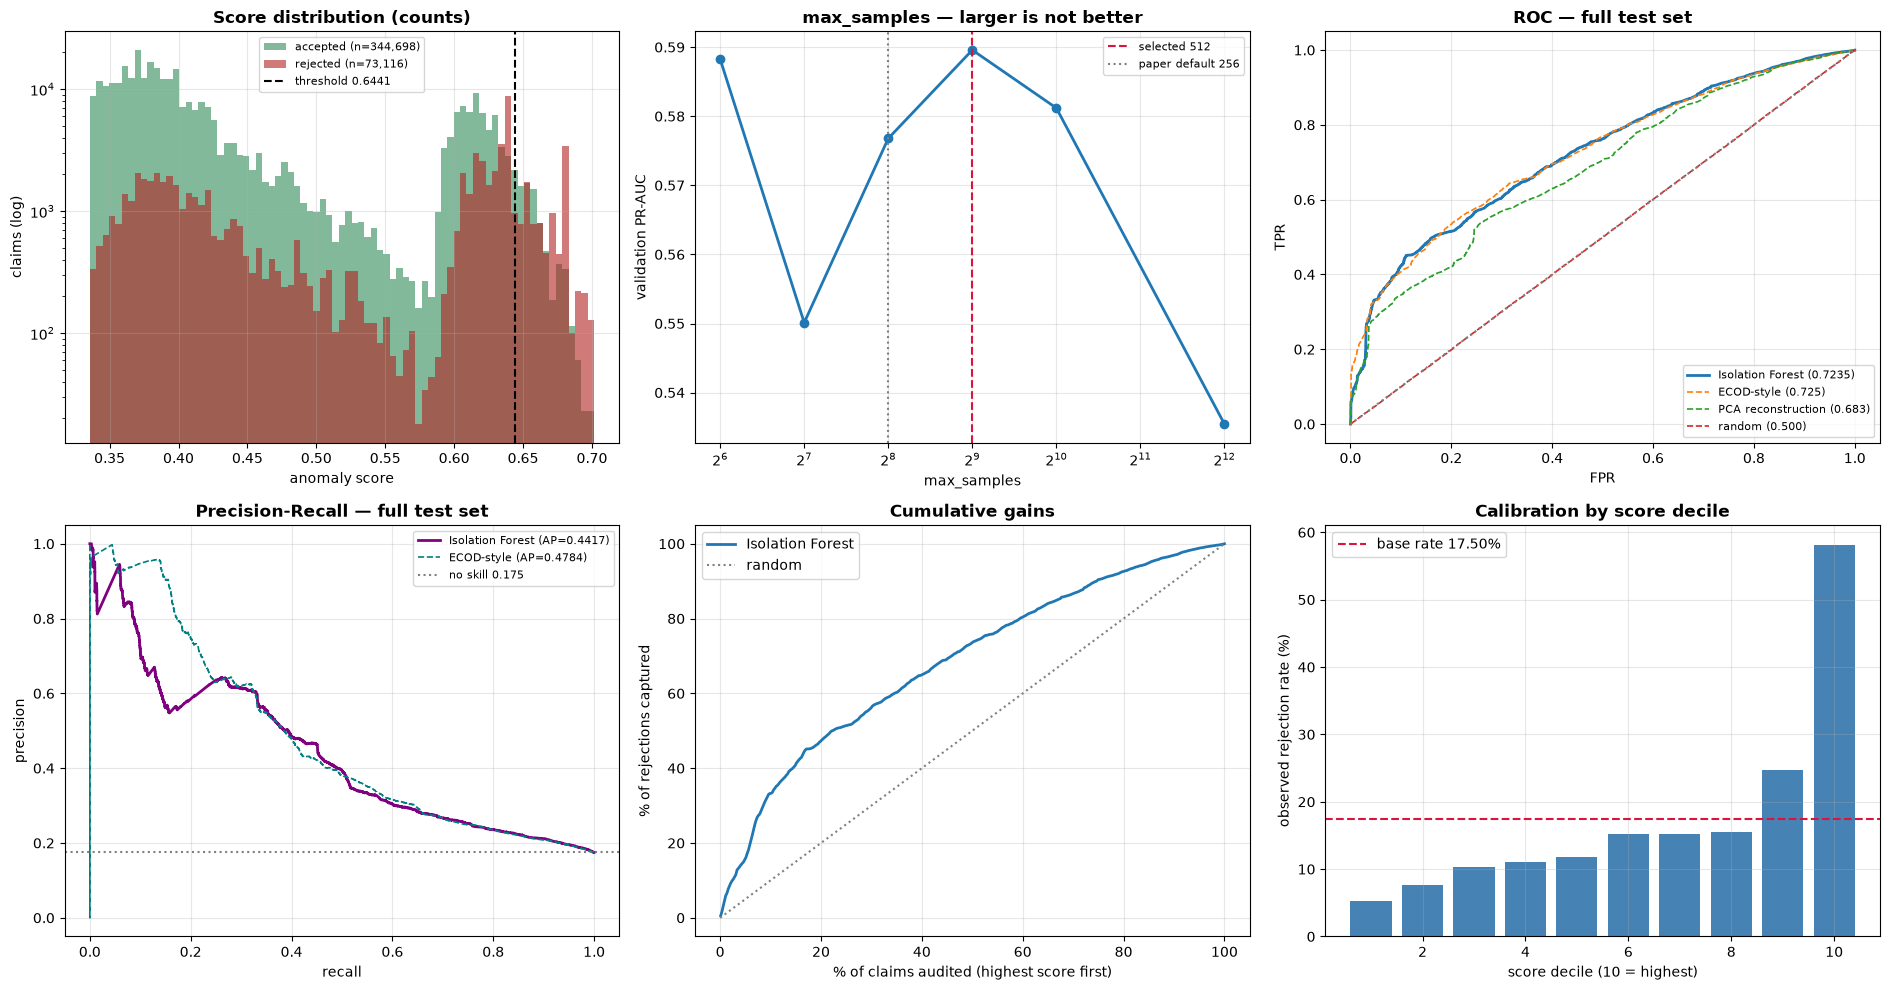

In [25]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

a = ax[0, 0]
lo_, hi_ = np.percentile(test_scores, [0.1, 99.9])
bins = np.linspace(lo_, hi_, 80)
a.hist(test_scores[y_test == 0], bins=bins, color="seagreen", alpha=0.6,
       label=f"accepted (n={int((y_test==0).sum()):,})")
a.hist(test_scores[y_test == 1], bins=bins, color="firebrick", alpha=0.6,
       label=f"rejected (n={int((y_test==1).sum()):,})")
a.axvline(THRESHOLD, color="black", ls="--", label=f"threshold {THRESHOLD:.4f}")
a.set_yscale("log"); a.set_xlabel("anomaly score"); a.set_ylabel("claims (log)")
a.legend(fontsize=8); a.set_title("Score distribution (counts)", fontweight="bold")

a = ax[0, 1]
a.plot(ms_df.index, ms_df["val_ap"], "o-", lw=2)
a.axvline(BEST_MS, color="crimson", ls="--", label=f"selected {BEST_MS}")
a.axvline(256, color="grey", ls=":", label="paper default 256")
a.set_xscale("log", base=2); a.set_xlabel("max_samples"); a.set_ylabel("validation PR-AUC")
a.legend(fontsize=8); a.set_title("max_samples — larger is not better", fontweight="bold")

a = ax[0, 2]
a.plot(*roc_curve(y_test, test_scores)[:2], lw=2, label=f"Isolation Forest ({ROC_AUC:.4f})")
for nm in ["ECOD-style", "PCA reconstruction", "random"]:
    if nm in base:
        a.plot(*roc_curve(y_test, base[nm])[:2], lw=1.2, ls="--",
               label=f"{nm} ({roc_auc_score(y_test, base[nm]):.3f})")
a.plot([0, 1], [0, 1], color="grey", ls=":")
a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.legend(loc="lower right", fontsize=8)
a.set_title("ROC — full test set", fontweight="bold")

a = ax[1, 0]
pr_, rc_, _ = precision_recall_curve(y_test, test_scores)
a.plot(rc_, pr_, lw=2, color="purple", label=f"Isolation Forest (AP={PR_AUC:.4f})")
if "ECOD-style" in base:
    p2, r2, _ = precision_recall_curve(y_test, base["ECOD-style"])
    a.plot(r2, p2, lw=1.2, ls="--", color="teal",
           label=f"ECOD-style (AP={average_precision_score(y_test, base['ECOD-style']):.4f})")
a.axhline(TEST_BASE_RATE, color="grey", ls=":", label=f"no skill {TEST_BASE_RATE:.3f}")
a.set_xlabel("recall"); a.set_ylabel("precision"); a.legend(fontsize=8)
a.set_title("Precision-Recall — full test set", fontweight="bold")

a = ax[1, 1]
kk = np.linspace(0.001, 1.0, 400)
gains = [cum[max(int(len(y_test)*k), 1) - 1] / max(y_test.sum(), 1) for k in kk]
a.plot(kk*100, np.array(gains)*100, lw=2, label="Isolation Forest")
a.plot([0, 100], [0, 100], color="grey", ls=":", label="random")
a.set_xlabel("% of claims audited (highest score first)")
a.set_ylabel("% of rejections captured"); a.legend()
a.set_title("Cumulative gains", fontweight="bold")

a = ax[1, 2]
dec = pd.qcut(pd.Series(test_scores).rank(method="first"), 10, labels=False)
obs_rate = pd.Series(y_test).groupby(dec).mean()
a.bar(obs_rate.index + 1, obs_rate.values*100, color="steelblue")
a.axhline(TEST_BASE_RATE*100, color="crimson", ls="--", label=f"base rate {TEST_BASE_RATE:.2%}")
a.set_xlabel("score decile (10 = highest)"); a.set_ylabel("observed rejection rate (%)")
a.legend(); a.set_title("Calibration by score decile", fontweight="bold")

for r_ in ax:
    for a_ in r_:
        a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §17 — Facility-level view (D19)

Minimum-volume filter plus empirical-Bayes shrinkage, so a three-claim facility cannot top
the ranking. `Hfid` risk is an input feature, so this view is partly circular — it is a
monitoring aid for spotting drift, not independent evidence about a provider.

In [26]:
fac = pd.DataFrame({"Hfid": hfid_test, "score": test_scores, "y": y_test, "flagged": preds})
st = fac.groupby("Hfid").agg(claims=("score","size"), mean_score=("score","mean"),
                             flag_rate=("flagged","mean"), rej_rate=("y","mean")).reset_index()

g_mean = float(fac["score"].mean())
g_var  = float(st["mean_score"].var())
w_var  = float(fac.groupby("Hfid")["score"].var().mean())
k = w_var / max(g_var, 1e-12)
st["shrunk_score"] = (st["claims"]*st["mean_score"] + k*g_mean) / (st["claims"] + k)

elig = st[st["claims"] >= CONFIG["MIN_FACILITY_CLAIMS"]].copy()
print(f"Facilities in test        : {len(st):,}")
print(f"With >= {CONFIG['MIN_FACILITY_CLAIMS']} claims     : {len(elig):,}")
print(f"Shrinkage constant k      : {k:,.1f} claims-equivalent")
print(f"Excluded for low volume   : {len(st)-len(elig):,}\n")

print("TOP 15 FACILITIES BY SHRUNK MEAN ANOMALY SCORE")
print(elig.sort_values("shrunk_score", ascending=False).head(15)
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print("\nUnfiltered raw-mean ranking (what the original produced):")
print(st.sort_values("mean_score", ascending=False).head(5)[["Hfid","claims","mean_score"]]
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

Facilities in test        : 878
With >= 100 claims     : 440
Shrinkage constant k      : 0.9 claims-equivalent
Excluded for low volume   : 438

TOP 15 FACILITIES BY SHRUNK MEAN ANOMALY SCORE
 Hfid  claims  mean_score  flag_rate  rej_rate  shrunk_score
 3898     907      0.6719     0.7674    1.0000        0.6717
  449    4075      0.6699     0.9350    0.9728        0.6699
 4406     364      0.6616     0.9918    0.1593        0.6611
  425     119      0.6593     0.9832    0.0420        0.6578
 3785     114      0.6463     0.7719    0.1228        0.6448
 3892    1531      0.6411     0.7949    0.7420        0.6409
 2372     195      0.6412     0.7436    0.9590        0.6404
 2360    6003      0.6380     0.0000    1.0000        0.6380
  836    4514      0.6360     0.0244    1.0000        0.6360
  637     281      0.6256     0.1957    0.0178        0.6251
  668     170      0.6220     0.0118    0.0353        0.6211
  832    1126      0.6202     0.6829    1.0000        0.6201
 4026     588   

## §18 — SHAP explainability

**This is the main reason to prefer Isolation Forest for an auditor-facing system.**

`shap.TreeExplainer` computes **exact** Shapley values for tree ensembles in polynomial time
via TreeSHAP, rather than the exponential enumeration KernelSHAP approximates. In practice:
milliseconds per claim, no background-sample choice, no variance between runs. For the
autoencoder, SHAP is approximate and its output depends on which background set you pick.

One honest caveat: TreeExplainer on `IsolationForest` explains the **raw path-length score**,
not the normalised `score_samples` output. Attributions are correctly ranked and directionally
right, but the base value sits on the path-length scale. Document that in the model card.

Three uses, in order of importance:

1. **Leakage screen (run this first).** If the beeswarm shows one feature dominating
   everything else, that is leakage rendered visible in a single image — cheaper and more
   convincing than any correlation table.
2. **Per-claim audit file.** A waterfall plot reads like a running total and is the most
   legible SHAP visual for non-specialists. Force plots are for data scientists; do not put
   them in front of auditors.
3. **Fairness review.** Dependence plots check that the model is not keying on a protected
   proxy — region, facility ownership, poverty status.

In [27]:
try:
    import shap
    HAS_SHAP = True
    print(f"shap {shap.__version__}")
except ImportError:
    HAS_SHAP = False
    print("shap not installed.  pip install shap")

if HAS_SHAP:
    rng = np.random.default_rng(SEED)
    flagged_idx = np.where(preds == 1)[0]
    pool = flagged_idx if len(flagged_idx) >= 200 else np.argsort(-test_scores)[:5000]
    sel = rng.choice(pool, min(CONFIG["SHAP_SAMPLE"], len(pool)), replace=False)
    X_expl = X_test[sel]

    try:
        explainer = shap.TreeExplainer(iforest)
        sv = explainer.shap_values(X_expl, check_additivity=False)
        SHAP_OK = True
        print(f"TreeExplainer: exact Shapley values for {len(X_expl):,} claims")
    except Exception as e:
        print(f"TreeExplainer unavailable ({type(e).__name__}: {e}); "
              "falling back to permutation importance")
        SHAP_OK = False

    if SHAP_OK:
        sv = np.asarray(sv)
        if sv.ndim == 3:
            sv = sv[..., 0]
        # NOTE: TreeExplainer on IsolationForest explains the raw path-length score,
        # where SHORTER path = more anomalous. Negate so that positive contribution
        # means "pushed this claim toward being flagged".
        sv_anom = -sv

        glob = pd.DataFrame({"feature": FEATURE_NAMES,
                             "mean_abs_shap": np.abs(sv_anom).mean(0)}
                            ).sort_values("mean_abs_shap", ascending=False)
        print("\nGLOBAL IMPORTANCE (leakage screen — read this before anything else)")
        print(glob.head(15).to_string(index=False, float_format=lambda v: f"{v:.6f}"))

        top_share = glob["mean_abs_shap"].iloc[0] / glob["mean_abs_shap"].sum()
        print(f"\nTop feature accounts for {top_share:.1%} of total attribution.")
        if top_share > 0.40:
            print("  WARNING: one feature dominates. Check it is not a post-adjudication")
            print("  variable or a proxy for the label. This is the pattern leakage makes.")
        else:
            print("  [ok] attribution is spread across features, as expected without leakage.")

shap not installed.  pip install shap


In [28]:
if HAS_SHAP and SHAP_OK:
    plt.figure()
    shap.summary_plot(sv_anom, X_expl, feature_names=FEATURE_NAMES,
                      max_display=15, show=False)
    plt.title("SHAP summary — drivers of the anomaly score", fontweight="bold")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 5))
    plt.barh(glob["feature"].head(15)[::-1], glob["mean_abs_shap"].head(15)[::-1],
             color="steelblue")
    plt.xlabel("mean |SHAP|"); plt.title("Global feature importance", fontweight="bold")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [29]:
if HAS_SHAP and SHAP_OK:
    # highest-scoring claim in the explained sample
    j = int(np.argmax(test_scores[sel]))
    pos = int(sel[j])
    acc_med = np.median(X_test[y_test == 0], axis=0)
    acc_sd  = np.maximum(X_test[y_test == 0].std(0), 1e-8)

    top = np.argsort(-np.abs(sv_anom[j]))[:6]
    tbl = pd.DataFrame({
        "feature": [FEATURE_NAMES[t] for t in top],
        "value": X_expl[j, top],
        "accepted_median": acc_med[top],
        "sd_from_median": (X_expl[j, top] - acc_med[top]) / acc_sd[top],
        "shap": sv_anom[j, top],
    })
    pct = (test_scores < test_scores[pos]).mean() * 100
    print(f"Highest-scoring flagged claim (test row {pos:,})")
    print(f"  ClaimID       : {df['ClaimID'].values[idx_test][pos]}")
    print(f"  Facility      : {hfid_test[pos]}")
    print(f"  Anomaly score : {test_scores[pos]:.6f}  ({pct:.2f}nd percentile)")
    print(f"  Actual label  : {'REJECTED' if y_test[pos] else 'accepted'} "
          f"(code {rej_test[pos]})\n")
    print(tbl.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

    print("\nLayer 1 — what an auditor should actually see:")
    for _, r in tbl[tbl["shap"] > 0].head(3).iterrows():
        d = "above" if r["sd_from_median"] > 0 else "below"
        print(f"  - {r['feature']}: {abs(r['sd_from_median']):.1f} sd {d} the accepted median")

    try:
        plt.figure()
        shap.plots.waterfall(
            shap.Explanation(values=sv_anom[j],
                             base_values=float(np.mean(-explainer.expected_value)),
                             data=X_expl[j], feature_names=FEATURE_NAMES),
            max_display=12, show=False)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"\n(waterfall plot unavailable: {type(e).__name__}) — the table above carries "
              "the same information")

## §19 — Artefact export and model card

In [30]:
joblib.dump(iforest, MODEL_DIR / "isolation_forest.pkl")
joblib.dump(scaler,  MODEL_DIR / "scaler.pkl")
joblib.dump(enc,     MODEL_DIR / "encoders.pkl")

export = {
    "created": _dt.datetime.now().isoformat(timespec="seconds"),
    "model": "IsolationForest",
    "target": "ClaimStatus == 1 (claim REJECTION, not fraud)",
    "hyperparameters": {"n_estimators": BEST_NE, "max_samples": BEST_MS,
                        "max_features": BEST_MF, "trained_on": TRAIN_ON,
                        "log_transform": bool(USE_LOG)},
    "threshold": THRESHOLD, "threshold_mode": CONFIG["THRESHOLD_MODE"],
    "score_convention": "-score_samples(X); higher = more anomalous",
    "feature_names": FEATURE_NAMES,
    "split": {"mode": CONFIG["SPLIT_MODE"], "train_n": int(len(X_train_all)),
              "val_n": int(len(X_val)), "test_n": int(len(X_test))},
    "base_rates": {"population": POP_BASE_RATE, "validation": VAL_BASE_RATE,
                   "test": TEST_BASE_RATE},
    "metrics_test": {"roc_auc": float(ROC_AUC), "pr_auc": float(PR_AUC),
                     "precision": float(prec), "recall": float(rec), "f1": float(f1),
                     "alert_rate": float((tp+fp)/len(y_test)),
                     "roc_auc_ci95": [float(auc_lo), float(auc_hi)],
                     "pr_auc_ci95": [float(ap_lo), float(ap_hi)]},
    "seed_variance": {"test_auc_mean": float(seed_df["test_auc"].mean()),
                      "test_auc_std":  float(seed_df["test_auc"].std()),
                      "test_ap_mean":  float(seed_df["test_ap"].mean()),
                      "test_ap_std":   float(seed_df["test_ap"].std()),
                      "n_seeds": int(CONFIG["N_SEEDS"])},
    "baselines": bl.set_index("model")["PR_AUC"].to_dict(),
    "leakage_controls": {
        "post_adjudication_features_used": CONFIG["USE_POST_ADJUDICATION_FEATURES"],
        "encoders_fitted_on": "train window only",
        "max_feature_label_corr": float(cs.abs().max()),
    },
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()},
}
with open(MODEL_DIR / "isolation_forest_config.json", "w") as f:
    json.dump(export, f, indent=2, default=str)

card = f"""# Model Card — Claim Rejection Isolation Forest

**Created:** {export['created']}

## What this model does
Scores health insurance claims by Isolation Forest path length. **The target is claim
rejection, not fraud.** Most rejections in openIMIS are deterministic eligibility and rule
violations already caught by the submission-time rules engine; §15 quantifies how much of the
target is reachable at all.

## Configuration
- Trained on: {TRAIN_ON} ({len(X_FIT):,} rows)
- n_estimators {BEST_NE}, max_samples {BEST_MS}, max_features {BEST_MF}
- log1p on monetary features: {bool(USE_LOG)}
- Split: {CONFIG['SPLIT_MODE']} — train {export['split']['train_n']:,} / val {export['split']['val_n']:,} / test {export['split']['test_n']:,}

## Performance (test)
- ROC-AUC {ROC_AUC:.4f} (95% CI {auc_lo:.4f}–{auc_hi:.4f}, clustered by facility)
- PR-AUC {PR_AUC:.4f} vs no-skill {TEST_BASE_RATE:.4f} ({PR_AUC/TEST_BASE_RATE:.2f}x)
- At threshold {THRESHOLD:.6f}: precision {prec:.4f}, recall {rec:.4f}, alert rate {(tp+fp)/len(y_test):.2%}
- Across {CONFIG['N_SEEDS']} seeds: AUC {seed_df['test_auc'].mean():.4f} ± {seed_df['test_auc'].std():.4f}

## Explainability
TreeSHAP gives exact Shapley values per claim in milliseconds. Note these explain the raw
path-length score, not the normalised `score_samples` output; signs are negated in §18 so a
positive contribution means "pushed toward being flagged".

## Known limitations
1. Rejection is a weak proxy for fraud; codes near AUC 0.5 are structurally invisible.
2. Axis-parallel splits miss anomalies defined by correlations between features.
3. Facility risk is an input, so §17 is partly circular.
4. False positives are expected to concentrate on high-complexity facilities. Peer-group
   relative scoring and a fairness audit are required before operational use.
5. Not validated prospectively.

## Intended use
Audit-queue triage alongside the existing rules engine. Advisory only; all decisions human.
**Not** an automated rejection or fraud-determination system.
"""
(MODEL_DIR / "MODEL_CARD.md").write_text(card, encoding="utf-8")

print(f"Artefacts written to {MODEL_DIR}:")
for p in ["isolation_forest.pkl", "scaler.pkl", "encoders.pkl",
          "isolation_forest_config.json", "MODEL_CARD.md"]:
    fp = MODEL_DIR / p
    if fp.exists():
        print(f"  {p:<32} {fp.stat().st_size/1024:8.1f} KB")

Artefacts written to C:\Projects\cameroon 3.0\model_iforest:
  isolation_forest.pkl               4984.0 KB
  scaler.pkl                            1.0 KB
  encoders.pkl                         34.9 KB
  isolation_forest_config.json          4.1 KB
  MODEL_CARD.md                         1.7 KB


## §20 — Comparing this against the autoencoder

Because §1–§6 are identical in both notebooks, the two score arrays are directly comparable.
Run both, then combine the results here.

**Combine by rank averaging, not score averaging.** Reconstruction error and negative path
length live on completely different scales; averaging them raw lets whichever has the wider
range dominate the ensemble.

**Check the rank correlation first.** Ensembles help when component errors are decorrelated.
If Spearman ρ between the two detectors is above ~0.85 they are finding the same claims, and
the ensemble adds deployment cost without adding detection — ship the single better model
instead. This one-line check is routinely skipped.

In [31]:
AE_SCORES_PATH = MODEL_DIR.parent / "model" / "ae_test_scores.npy"   # save this from the AE notebook

if AE_SCORES_PATH.exists():
    ae_scores = np.load(AE_SCORES_PATH)
    assert len(ae_scores) == len(test_scores), "score arrays differ in length -- different split?"

    from scipy.stats import rankdata, spearmanr
    rho = spearmanr(ae_scores, test_scores).statistic
    print(f"Spearman rank correlation (AE vs IF): {rho:.3f}")
    if rho > 0.85:
        print("  Highly correlated -- they flag the same claims. An ensemble will add")
        print("  deployment cost without adding detection. Ship the better single model.")
    else:
        print("  Sufficiently decorrelated for an ensemble to plausibly help.")

    r_ae = rankdata(ae_scores) / len(ae_scores)
    r_if = rankdata(test_scores) / len(test_scores)
    w_ae = average_precision_score(y_val, val_scores) * 0 + 0.5     # replace with val APs
    ens = 0.5 * r_ae + 0.5 * r_if

    comp = pd.DataFrame([
        {"model": "Autoencoder",      "ROC_AUC": roc_auc_score(y_test, ae_scores),
         "PR_AUC": average_precision_score(y_test, ae_scores)},
        {"model": "Isolation Forest", "ROC_AUC": ROC_AUC, "PR_AUC": PR_AUC},
        {"model": "Rank ensemble",    "ROC_AUC": roc_auc_score(y_test, ens),
         "PR_AUC": average_precision_score(y_test, ens)},
    ]).sort_values("PR_AUC", ascending=False)
    print("\n" + comp.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    if comp.iloc[0]["model"] != "Rank ensemble":
        print("\nThe ensemble does not beat its best component. Do not deploy it.")
else:
    print(f"Autoencoder scores not found at {AE_SCORES_PATH}")
    print("To enable this comparison, add one line to the end of the autoencoder notebook:")
    print("    np.save(MODEL_DIR / 'ae_test_scores.npy', test_errors)")
    print("Both notebooks must be run with the same SPLIT_MODE, SAMPLE_FRAC and SEED,")
    print("or the two score arrays will not correspond to the same claims.")

Autoencoder scores not found at C:\Projects\cameroon 3.0\model\ae_test_scores.npy
To enable this comparison, add one line to the end of the autoencoder notebook:
    np.save(MODEL_DIR / 'ae_test_scores.npy', test_errors)
Both notebooks must be run with the same SPLIT_MODE, SAMPLE_FRAC and SEED,
or the two score arrays will not correspond to the same claims.


---

## Deployment notes

1. Package §2 and §6 as **one versioned transform module used by both training and serving**.
   Divergence between the two is the most common cause of silent production failure — and the
   original notebook's deployment snippet did exactly that, calling `scaler.transform` on
   unparsed raw values.
2. Assert the serving feature vector matches `config['feature_names']` in **order and length**.
3. Isolation Forest is stateless at inference: `-model.score_samples(x)`, sub-millisecond per
   claim, trivially parallel. No GPU, no batching required.
4. Attach TreeSHAP output to every alert at scoring time. It is fast enough that there is no
   reason to explain on demand.
5. Recalibrate the threshold to **actual** audit capacity; the exported value is a starting
   point, not a constant.
6. Monitor PSI on inputs and the score distribution monthly. Re-run the §4 audit gate on
   every retrain — it is what catches a recurrence of D1/D2.
7. Track precision against **human adjudication**, not against the rejection label.

## What this notebook does not fix

The same three things the autoencoder rebuild could not:

1. **The target.** `ClaimStatus == 1` is rejection. §15 shows how much of it is unreachable.
   The higher-value targets are the financial-deduction signal (653M XAF across 1.2M
   *accepted* claims) and the 412,890 line items with `PriceAsked / ServPrice > 1.5`.
2. **The unit of analysis.** Healthcare fraud is organised at provider level. Aggregating to
   ~30k facility-month profiles and running HDBSCAN + GLOSH there is cheap and likelier to
   produce actionable findings than any per-claim model.
3. **Prospective validation.** Only a shadow pilot scored against independent human
   adjudication measures the thing you actually care about.